# 04 — Behavioural Rhythm

## What rhythm means here

Two participants did the identical 26-task sequence. One took **15:56**, another **2:12**.
Watching it happen, the difference was not subtle — every tap preceded by a pause, every
field hunted for. This notebook is about making that visible in the data, and then asking
what *kinds* of rhythm exist beyond the obvious one.

**Rhythm is tempo, not magnitude.** Most per-event measurements — how hard a tap was, how
far a scroll travelled, how fast a finger moved — describe a single gesture in isolation.
Rhythm is the opposite: it lives in the *relationships between* events. How often. How long
between. How regular. When nothing happens at all.

That distinction matters because a magnitude-only view is blind to the 7x difference above.
Both participants tapped with roughly the same force; one just did it far less often, with
long silences in between.

## The rhythm vocabulary

Everything in this notebook is one of six kinds of measurement. Worth having the
distinctions clear before any of them are computed:

| kind | what it physically is | example |
|---|---|---|
| **interval** | time from one event to the next of the same type | inter-tap interval |
| **rate** | events per unit time over a window | taps per second |
| **silence** | time with no events at all | idle fraction, longest pause |
| **burst** | a cluster of events, and the gaps between clusters | a scroll gesture |
| **regularity** | how *consistent* the intervals are, independent of their length | metronomic vs erratic |
| **duration** | how long a single event lasts | how long a finger rests on glass |

A person can be distinctive on any of these independently. Someone can be slow but perfectly
regular; fast but erratic; quick-fingered but full of long pauses. Collapsing all of it to
"pace" loses most of the structure.

## What this notebook is not

It does not score features, rank them, or evaluate whether they separate people. With this
cohort and overlapping windows, no number here could support that. The plots are the output;
the reading is yours.

## Sections

1. Setup, and the cohort
2. Session tempo, in one plot
3. The interaction raster — looking at the raw stream
4. Affordance: where each signal is even meaningful
5. Intervals — the core rhythmic unit
6. Silence — pauses as first-class observations
7. Bursts — rhythm above the level of single events
8. Regularity — metronomic or erratic
9. Rhythm over session time — drift, practice, fatigue
10. Task-entry latency — hesitation at a boundary
11. Modality switching — how attention moves between channels
12. Durations — how long events last, and the dwell trap
13. Distribution shape — why medians lie
14. Per-modality rhythm side by side
15. Availability — who can be measured on what
16. Data-quality notes and rejected derivations
17. Per-participant rhythm cards
18. Open questions

## 1. Setup, and the cohort

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

# --- event vocabulary -------------------------------------------------------
TAP_DOWN, TAP_UP, TAP_MOVE = 'touchstart', 'touchend', 'touchmove'
KEY_DOWN, KEY_UP = 'keydown', 'keyup'
SCROLL_KINDS = ['scroll', 'window_scroll', 'carousel_scroll']
INTERACTION_KINDS = [TAP_DOWN, TAP_UP, KEY_DOWN, KEY_UP, 'input'] + SCROLL_KINDS + \
                    ['pointerdown', 'pointerup', 'click']

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}

# sessions ordered slowest-first: on identical work, duration IS the tempo summary
SESSION_ORDER = session_index.sort_values('duration_s', ascending=False)['sessionId'].tolist()
_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()

_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')


def ev_times(sess, kinds):
    # Sorted event timestamps in seconds for one session.
    if isinstance(kinds, str):
        kinds = [kinds]
    return np.sort(sess.loc[sess['kind'].isin(kinds), 'tRelMs'].to_numpy(float)) / 1000.0


print(f"Loaded {_src}")
print(f"mobile: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants")
print(f"\nparticipants ordered slowest-first by median session duration:")
for p in PARTICIPANTS:
    d = session_index.loc[session_index['participantId'] == p, 'duration_s']
    print(f"  {p}  {len(d)} session(s)  median {d.median()/60:5.1f} min  "
          f"range {d.min()/60:.1f}-{d.max()/60:.1f} min")

Loaded ../../data/processed/raw_events.parquet
mobile: 28 sessions, 10 participants

participants ordered slowest-first by median session duration:
  p3M6E7Z  1 session(s)  median  15.9 min  range 15.9-15.9 min
  pAFQRTM  1 session(s)  median  11.7 min  range 11.7-11.7 min
  p95MPVX  3 session(s)  median   8.3 min  range 5.4-12.0 min
  pZMC82M  1 session(s)  median   7.3 min  range 7.3-7.3 min
  pWS9VTN  1 session(s)  median   6.8 min  range 6.8-6.8 min
  pUNKH7L  1 session(s)  median   6.0 min  range 6.0-6.0 min
  pH3S4X4  8 session(s)  median   6.0 min  range 4.2-11.3 min
  pA6XL23  2 session(s)  median   5.3 min  range 4.3-6.3 min
  p3YDMHG  4 session(s)  median   5.1 min  range 4.8-6.7 min
  pG5G4MS  6 session(s)  median   2.3 min  range 2.1-2.5 min


## 2. Session tempo, in one plot

Cumulative tasks completed against elapsed time. Every session runs the identical 26-task
sequence, so **the slope of each line is that session's tempo and nothing else**. A line
reaching the top-left is fast; one crawling along the bottom is slow. Flat segments are
someone stuck on a single task.

This needs no feature engineering at all — only the `task_start` events. It is the plainest
possible statement of what this notebook is about.

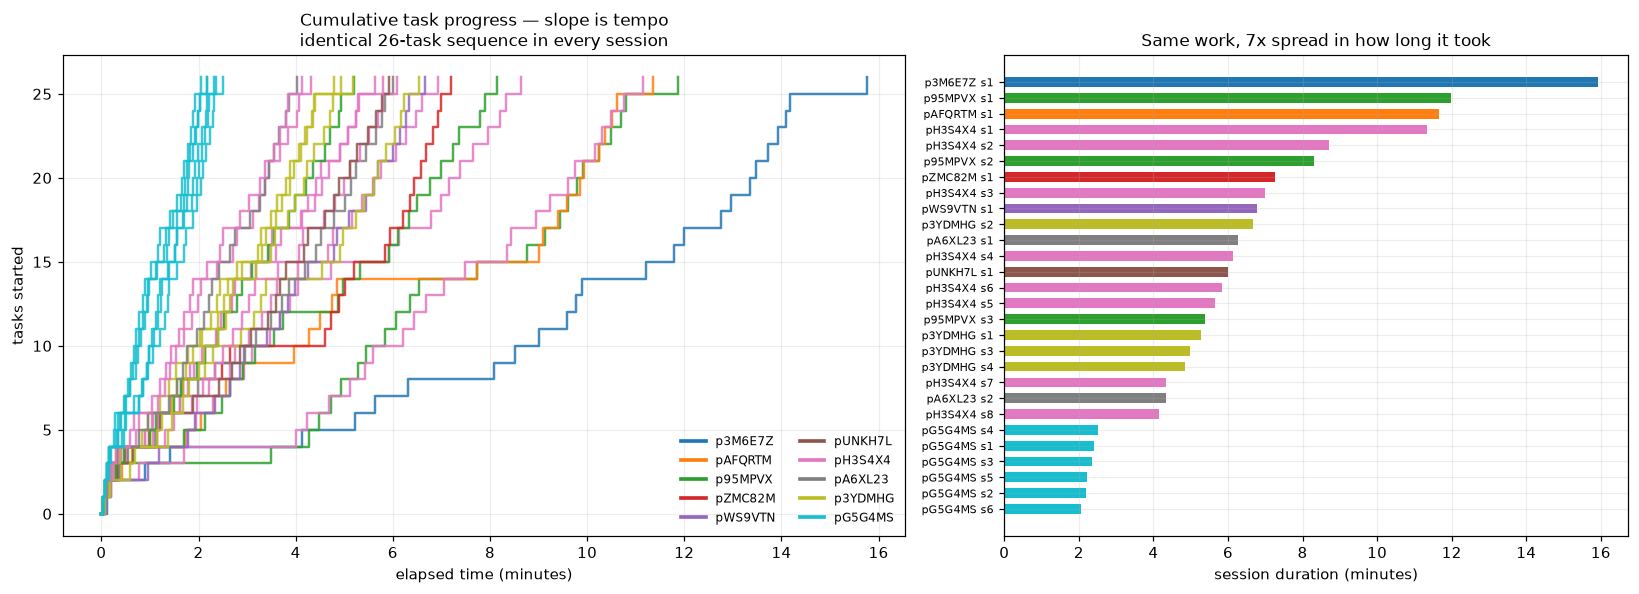

In [2]:
def plot_task_progress(raw_df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.35, 1]})

    ax = axes[0]
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        t = ev_times(s, 'task_start') / 60.0
        if len(t) == 0:
            continue
        p = s['participantId'].iloc[0]
        ax.step(np.concatenate([[0], t]), np.arange(0, len(t) + 1), where='post',
                color=pcolor(p), lw=1.6, alpha=0.85)
    ax.set_xlabel("elapsed time (minutes)"); ax.set_ylabel("tasks started")
    ax.set_title("Cumulative task progress — slope is tempo\n"
                 "identical 26-task sequence in every session")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, fontsize=8, frameon=False, loc='lower right', ncol=2)

    ax = axes[1]
    d = session_index.sort_values('duration_s')
    y = np.arange(len(d))
    ax.barh(y, d['duration_s'] / 60.0, color=[pcolor(p) for p in d['participantId']], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels([SESSION_LABEL[s] for s in d['sessionId']], fontsize=7.5)
    ax.set_xlabel("session duration (minutes)")
    ax.set_title("Same work, 7x spread in how long it took")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_task_progress(raw)

## 3. The interaction raster — looking at the raw stream

One vertical tick per interaction event. No binning, no aggregation — the closest thing to
looking directly at the raw stream. Three lanes per session: typing, tapping, scrolling.

**Read the white space.** Dense black is continuous interaction; every gap is a pause. This
is the plot where silence becomes the visually dominant feature, because idle time is drawn
as itself rather than as an absence of data points.

Sessions run slowest at the top, so the gradient reads downward.

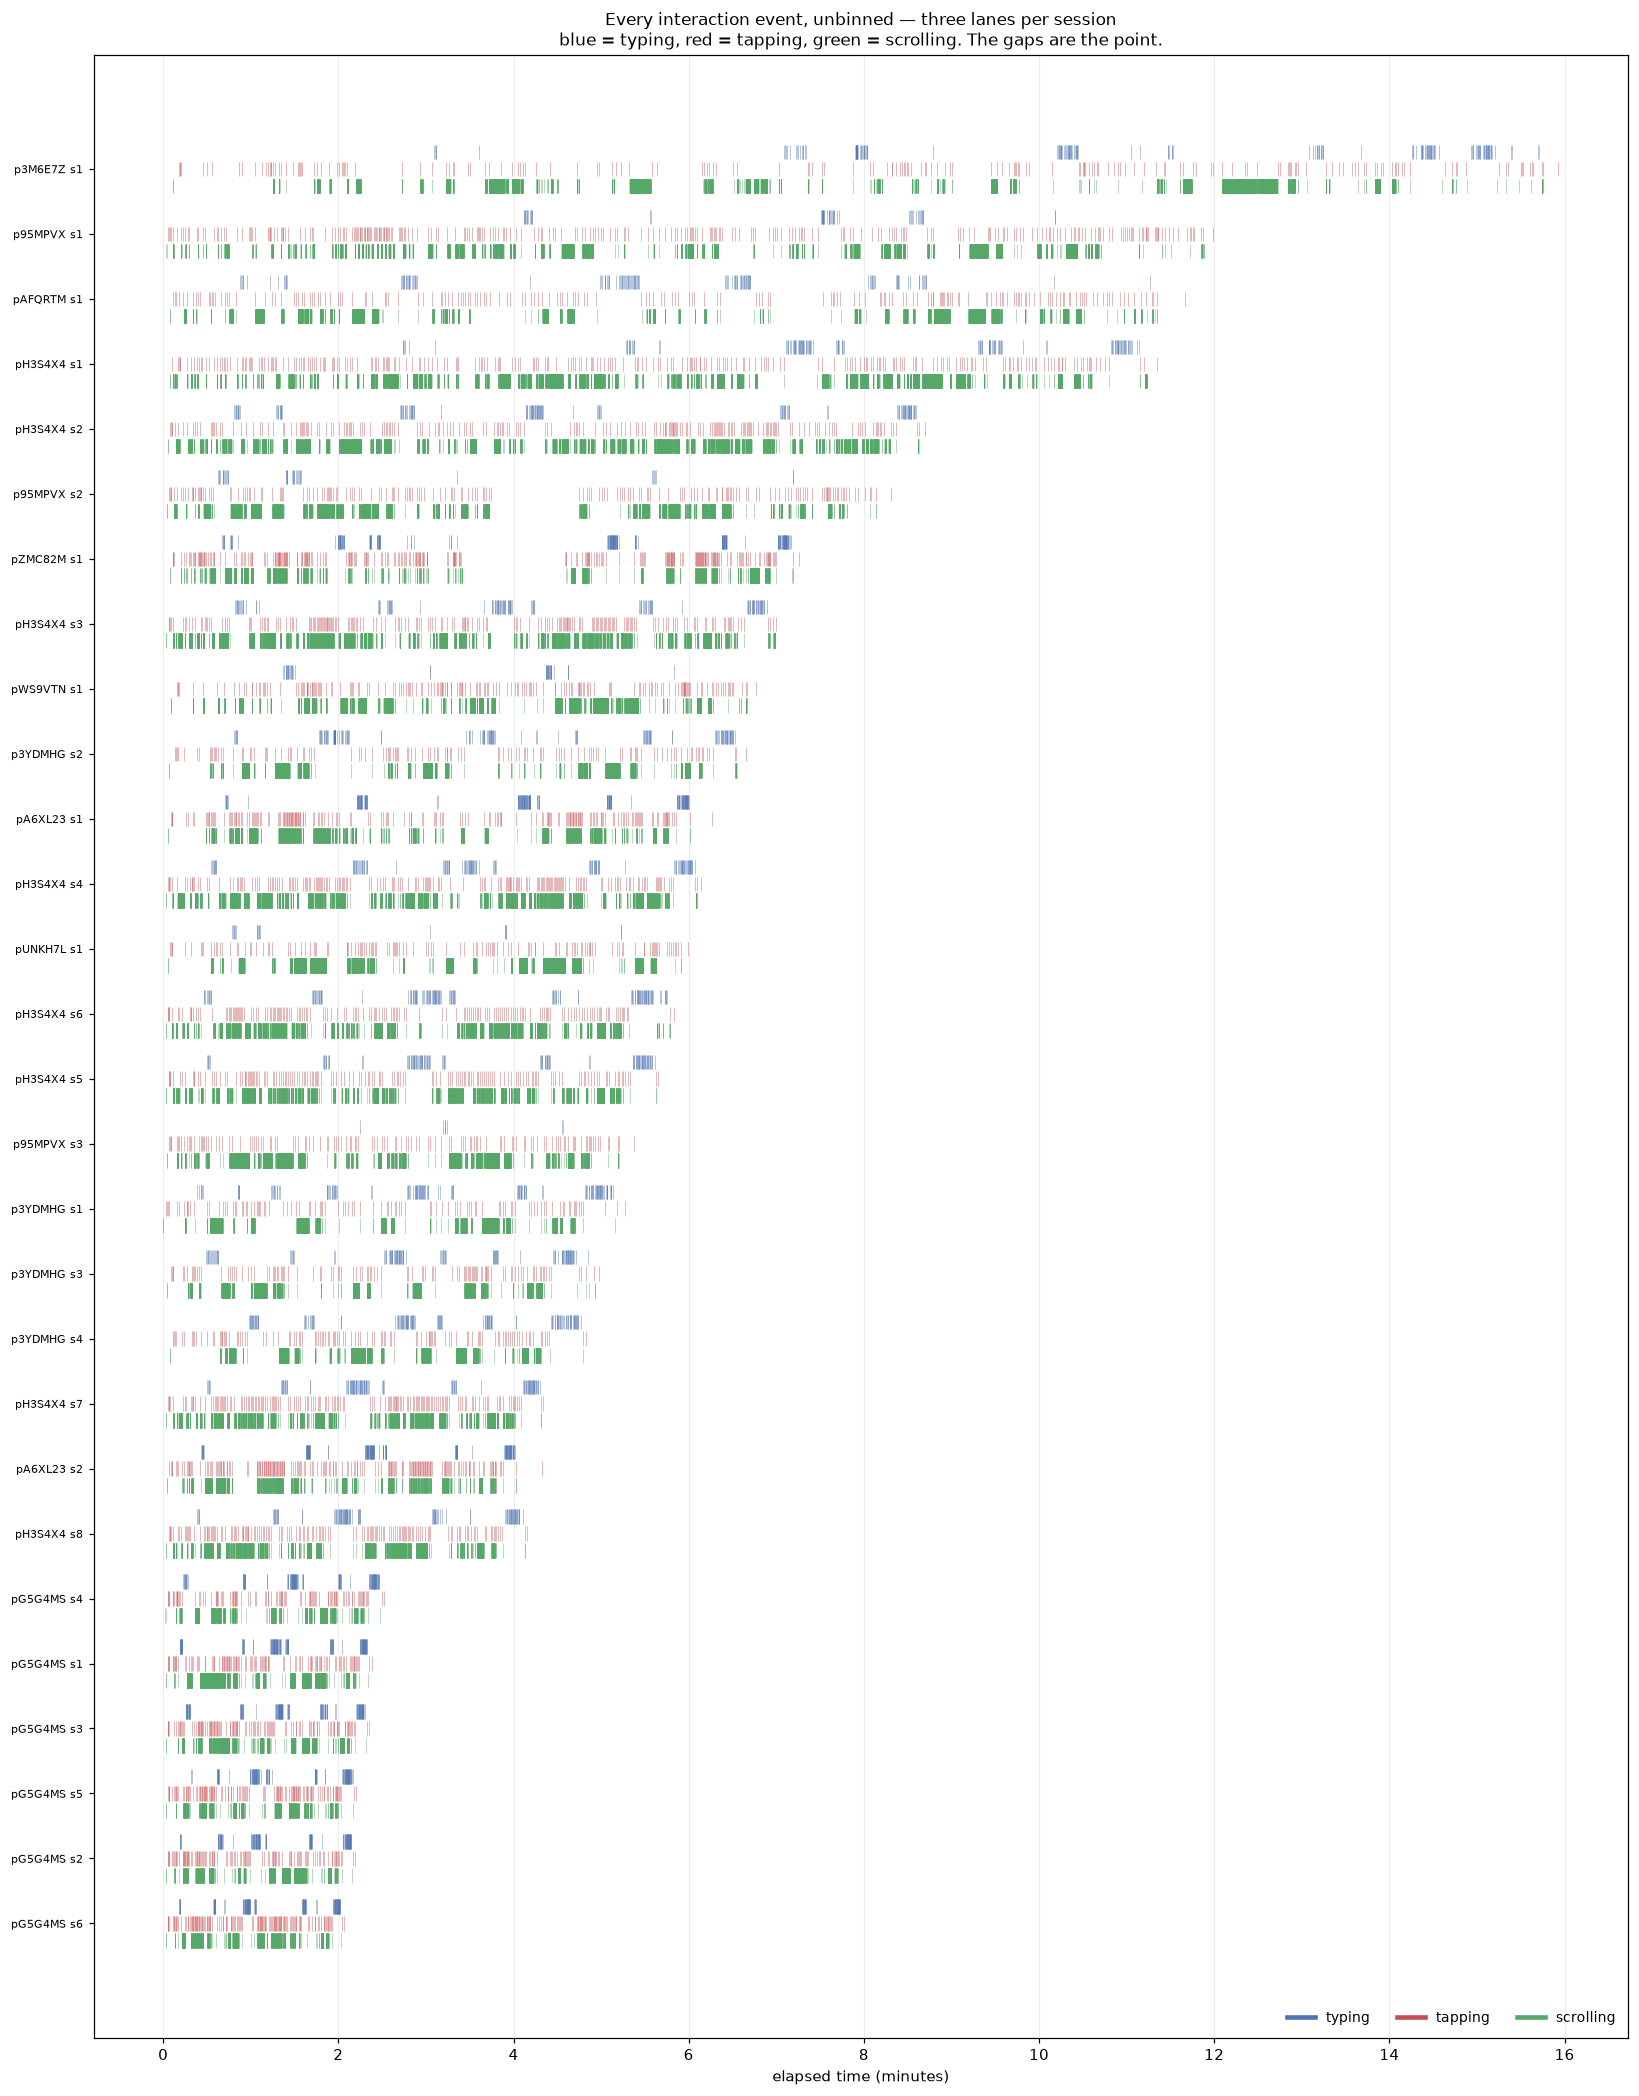

In [3]:
LANES = [('typing', [KEY_DOWN], '#4c72b0'),
         ('tapping', [TAP_DOWN], '#c44e52'),
         ('scrolling', SCROLL_KINDS, '#55a868')]


def plot_raster(raw_df, max_minutes=None):
    n = len(SESSION_ORDER)
    fig, ax = plt.subplots(figsize=(15, 0.62 * n + 1.8))
    yticks, ylabels = [], []
    for row, sid in enumerate(SESSION_ORDER):
        s = raw_df.loc[raw_df['sessionId'] == sid]
        base = row * 1.0
        for li, (name, kinds, c) in enumerate(LANES):
            t = ev_times(s, kinds) / 60.0
            if len(t) == 0:
                continue
            yy = base + (li - 1) * 0.26
            ax.vlines(t, yy - 0.11, yy + 0.11, color=c, lw=0.35, alpha=0.75)
        yticks.append(base); ylabels.append(SESSION_LABEL[sid])
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel("elapsed time (minutes)")
    if max_minutes:
        ax.set_xlim(0, max_minutes)
    ax.set_title("Every interaction event, unbinned — three lanes per session\n"
                 "blue = typing, red = tapping, green = scrolling. The gaps are the point.")
    handles = [Line2D([0], [0], color=c, lw=3, label=name) for name, _, c in LANES]
    ax.legend(handles=handles, fontsize=9, frameon=False, ncol=3, loc='lower right')
    ax.grid(axis='y', alpha=0)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_raster(raw)

## 4. Affordance: where each signal is even meaningful

A rhythm signal should only be read where the task calls for it. Plotting typing rhythm
during a scrolling task is not measuring a quiet typist — it is measuring nothing, and
averaging that nothing into a distribution drags every participant toward the same value.

**But inactivity has two causes and only one is meaningless.**

- If the task does not afford typing, no typing is uninformative.
- If the task *does* afford typing and the person still is not typing, that silence is
  **hesitation** — one of the strongest signals in this dataset.

So the affordance map has to key on **what the task offers**, never on **whether events were
observed**. Keying on observed activity would delete exactly the behaviour worth measuring.

The map below is derived from the data rather than hardcoded: for each task type, the
fraction of instances in which that modality produced at least one event.

Fraction of task instances in which each modality produced at least one event:

                  n_instances  typing  tapping  scrolling
taskType                                                 
pots_transfer              56    1.00      1.0       1.00
typing_search              56    0.98      1.0       1.00
guided_reply               56    0.84      1.0       1.00
guided_note                56    0.80      1.0       1.00
activity_filter            56    0.00      1.0       0.62
card_swipe                 56    0.00      1.0       1.00
categorise                 56    0.00      1.0       1.00
code                       28    0.00      1.0       1.00
finish                     28    0.00      1.0       0.75
home_explore               28    0.00      1.0       1.00
insights_review            56    0.00      1.0       1.00
pot_drag                   56    0.00      1.0       0.77
swipe_approval             56    0.00      1.0       0.79
tap_account                28    0.00      1.0    

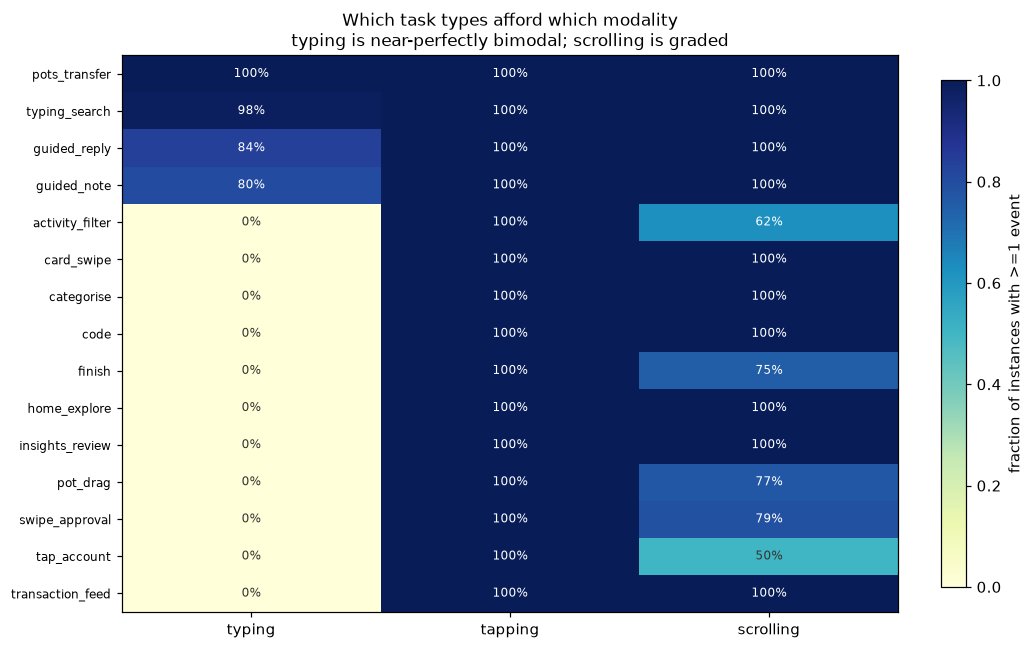

In [4]:
MODALITY_KINDS = {'typing': [KEY_DOWN], 'tapping': [TAP_DOWN], 'scrolling': SCROLL_KINDS}


def build_task_timeline(raw_df):
    ts = raw_df.loc[raw_df['kind'] == 'task_start',
                    ['sessionId', 'tRelMs', 'taskId', 'payload_taskType']].copy()
    ts = ts.sort_values(['sessionId', 'tRelMs'])
    ts['t_start_s'] = ts['tRelMs'] / 1000.0
    ts['t_end_s'] = ts.groupby('sessionId')['t_start_s'].shift(-1)
    ends = raw_df.groupby('sessionId')['tRelMs'].max() / 1000.0
    ts['t_end_s'] = ts['t_end_s'].fillna(ts['sessionId'].map(ends))
    return ts


timeline = build_task_timeline(raw)


def affordance_map(raw_df, timeline):
    rows = []
    for (ttype), grp in timeline.groupby('payload_taskType'):
        rec = {'taskType': ttype, 'n_instances': len(grp)}
        for mod, kinds in MODALITY_KINDS.items():
            hits = 0
            for r in grp.itertuples():
                s = raw_df.loc[raw_df['sessionId'] == r.sessionId]
                t = ev_times(s, kinds)
                if ((t >= r.t_start_s) & (t < r.t_end_s)).any():
                    hits += 1
            rec[mod] = hits / len(grp)
        rows.append(rec)
    return pd.DataFrame(rows).set_index('taskType').sort_values('typing', ascending=False)


afford = affordance_map(raw, timeline)
print("Fraction of task instances in which each modality produced at least one event:\n")
print(afford.round(2).to_string())


def plot_affordance(afford):
    fig, ax = plt.subplots(figsize=(9.5, 6))
    mods = list(MODALITY_KINDS)
    data = afford[mods].to_numpy()
    im = ax.imshow(data, cmap='YlGnBu', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(mods))); ax.set_xticklabels(mods)
    ax.set_yticks(range(len(afford))); ax.set_yticklabels(afford.index, fontsize=8)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.0%}", ha='center', va='center', fontsize=8,
                    color='white' if data[i, j] > 0.55 else '0.2')
    ax.set_title("Which task types afford which modality\n"
                 "typing is near-perfectly bimodal; scrolling is graded")
    ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.03, label="fraction of instances with >=1 event")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_affordance(afford)

Typing comes out **near-perfectly bimodal** — a task type either affords it in essentially
every instance or in none. Nothing hinges on where a threshold sits. Scrolling is graded,
which is the honest result: some tasks invite scrolling without requiring it.

The practical consequence for everything below: **rate** features (events per second) are
only read inside afforded tasks, because a rate has time in its denominator and returns a
real-looking `0` where the modality was never possible. **Interval** features need no such
mask — an interval only exists where two events actually happened.

## 5. Intervals — the core rhythmic unit

An interval is the time from one event to the next of the same type. It is the most direct
rhythmic measurement there is, and each one means something physically different:

| interval | between | what it physically measures |
|---|---|---|
| **inter-tap** | `touchstart` -> `touchstart` | how often a finger strikes the glass — includes deciding where to tap |
| **press-to-press** | `keydown` -> `keydown` | typing cadence, key to key |
| **release-to-press** | `keyup` -> `keydown` | the *flight* time between keys, with the hold removed |
| **inter-scroll-burst** | one scroll gesture -> the next | how often someone re-pushes the page |

Note what is deliberately absent: **inter-scroll-event** interval. Individual scroll events
fire on a browser throttle (roughly every 30 ms), so the gap between two of them measures the
throttle, not the person. The rhythmic unit for scrolling is the *burst*, which Section 7
handles.

The plots below are empirical CDFs on a log axis: every interval a participant produced,
plotted as a curve rather than collapsed to a median. A curve sitting **left** is faster. The
vertical distance between curves at a given x is how differently those people behave at that
timescale.

In [5]:
def intervals_for(sess, kinds):
    t = ev_times(sess, kinds)
    return np.diff(t) * 1000.0 if len(t) > 1 else np.array([])


def flight_intervals(sess):
    # keyup -> next keydown: the flight time between keys, hold removed
    kd = ev_times(sess, KEY_DOWN); ku = ev_times(sess, KEY_UP)
    if len(kd) < 2 or len(ku) < 1:
        return np.array([])
    out = []
    for i in range(len(ku)):
        nxt = kd[kd > ku[i]]
        if len(nxt):
            out.append((nxt[0] - ku[i]) * 1000.0)
    return np.array(out)


def burst_starts(sess, kinds, gap_ms=300.0):
    t = ev_times(sess, kinds) * 1000.0
    if len(t) == 0:
        return np.array([])
    brk = np.where(np.diff(t) > gap_ms)[0]
    groups = np.split(t, brk + 1)
    return np.array([g[0] for g in groups])


INTERVAL_DEFS = {
    'inter-tap': lambda s: intervals_for(s, TAP_DOWN),
    'press-to-press (typing)': lambda s: intervals_for(s, KEY_DOWN),
    'release-to-press (flight)': flight_intervals,
    'inter-scroll-burst': lambda s: np.diff(burst_starts(s, SCROLL_KINDS)),
}


def collect_intervals(raw_df):
    out = {}
    for name, fn in INTERVAL_DEFS.items():
        per_p = {}
        for p in PARTICIPANTS:
            vals = []
            for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
                v = fn(raw_df.loc[raw_df['sessionId'] == sid])
                v = v[np.isfinite(v) & (v > 0)]
                vals.append(v)
            per_p[p] = np.concatenate(vals) if vals else np.array([])
        out[name] = per_p
    return out


IV = collect_intervals(raw)
summary_rows = []
for name, per_p in IV.items():
    for p, v in per_p.items():
        if len(v):
            summary_rows.append({'interval': name, 'participant': p, 'n': len(v),
                                 'p10': np.percentile(v, 10), 'median': np.median(v),
                                 'p90': np.percentile(v, 90)})
iv_summary = pd.DataFrame(summary_rows)
print("Interval summaries (ms). Note how far apart p90 is from the median --")
print("hesitation lives in the tail, and a median throws it away.\n")
print(iv_summary.round(0).to_string(index=False))

Interval summaries (ms). Note how far apart p90 is from the median --
hesitation lives in the tail, and a median throws it away.

                 interval participant    n    p10  median     p90
                inter-tap     p3M6E7Z  193  799.0  2531.0 11617.0
                inter-tap     pAFQRTM  190  918.0  2403.0  6664.0
                inter-tap     p95MPVX  597  676.0  1800.0  5166.0
                inter-tap     pZMC82M  281  316.0   562.0  3127.0
                inter-tap     pWS9VTN  188  434.0  1265.0  4543.0
                inter-tap     pUNKH7L  135  649.0  1533.0  6042.0
                inter-tap     pH3S4X4 1478  683.0  1318.0  4387.0
                inter-tap     pA6XL23  405  433.0   665.0  3581.0
                inter-tap     p3YDMHG  455  681.0  1780.0  5895.0
                inter-tap     pG5G4MS  723  382.0   566.0  2245.0
  press-to-press (typing)     p3M6E7Z  164  183.0   449.0  2742.0
  press-to-press (typing)     pAFQRTM  125  266.0   552.0  4097.0
  press-to-p

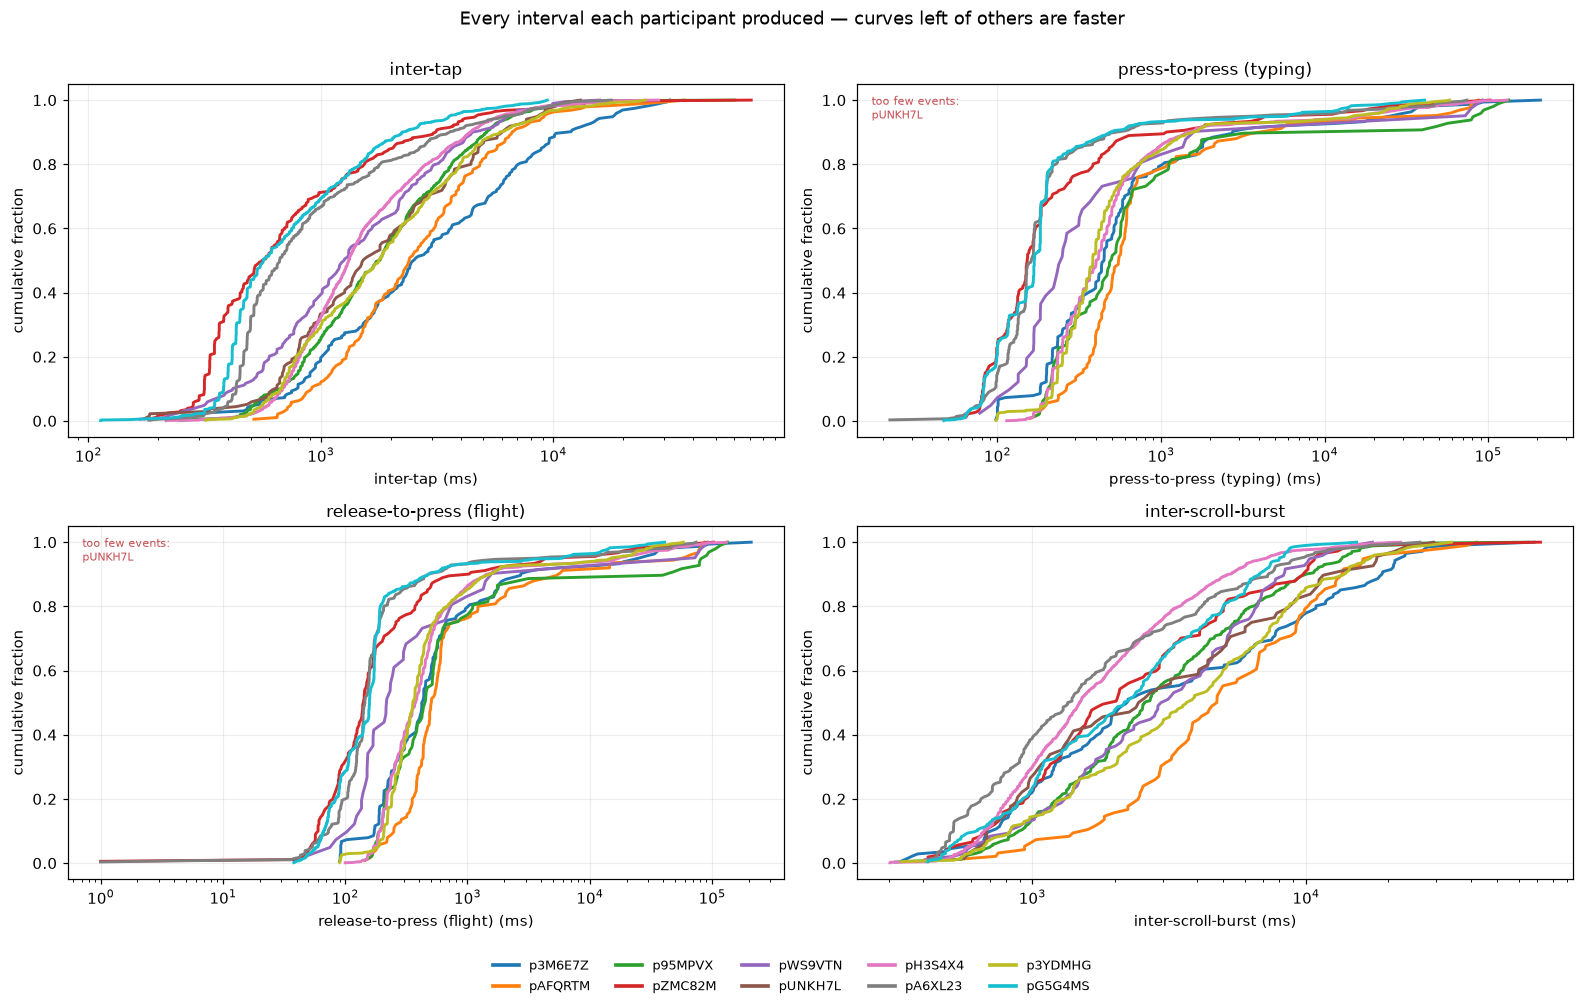

In [6]:
def plot_interval_ecdfs(IV):
    names = list(IV)
    fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))
    for ax, name in zip(axes.ravel(), names):
        missing = []
        for p in PARTICIPANTS:
            v = IV[name][p]
            v = v[v > 0]
            if len(v) < 20:
                missing.append(p); continue
            v = np.sort(v)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xscale('log'); ax.set_xlabel(f"{name} (ms)"); ax.set_ylabel("cumulative fraction")
        ax.set_title(name)
        if missing:
            ax.text(0.02, 0.97, "too few events:\n" + ", ".join(missing),
                    transform=ax.transAxes, va='top', fontsize=7.5, color='#c44e52')
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    fig.suptitle("Every interval each participant produced — curves left of others are faster",
                 y=1.0)
    plt.tight_layout(rect=[0, 0.055, 1, 1]); plt.show(); plt.close(fig)


plot_interval_ecdfs(IV)

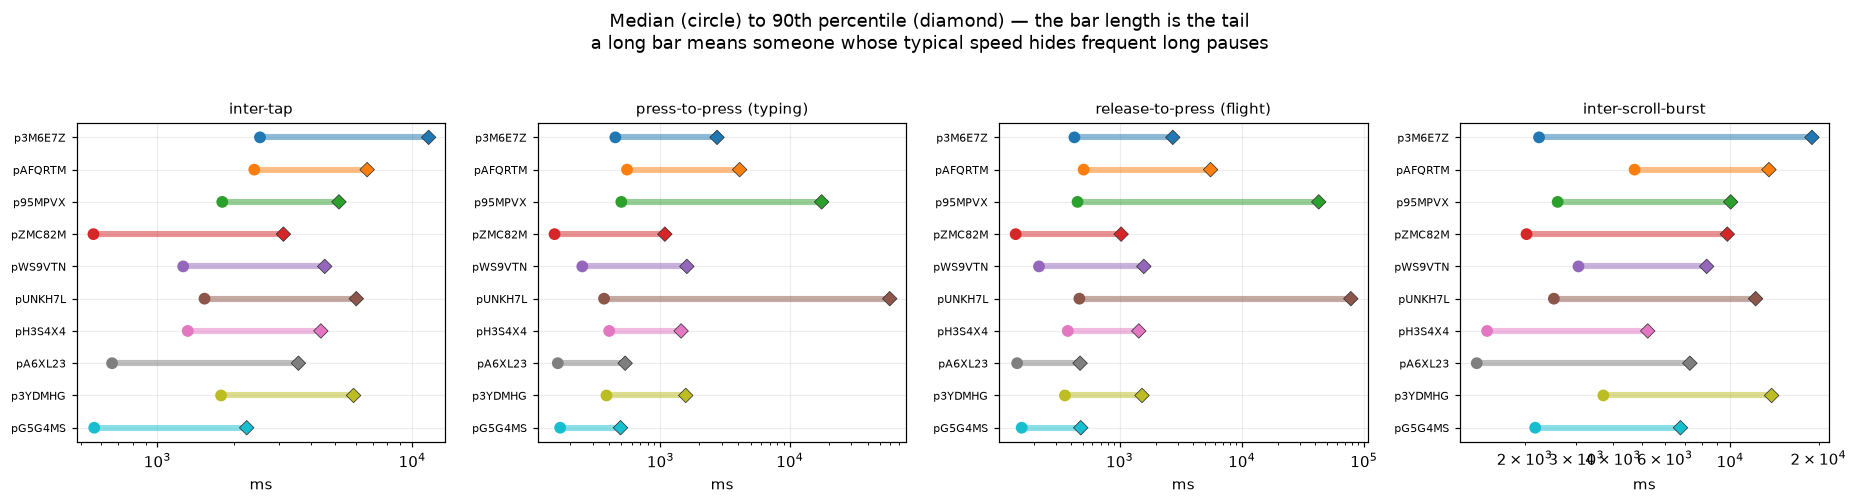

In [7]:
def plot_median_vs_tail(iv_summary):
    names = list(INTERVAL_DEFS)
    fig, axes = plt.subplots(1, len(names), figsize=(17, 4.4), sharey=False)
    for ax, name in zip(axes, names):
        d = iv_summary.loc[iv_summary['interval'] == name].set_index('participant')
        d = d.reindex([p for p in PARTICIPANTS if p in d.index])
        y = np.arange(len(d))
        ax.hlines(y, d['median'], d['p90'], color=[pcolor(p) for p in d.index], lw=4, alpha=0.5)
        ax.scatter(d['median'], y, color=[pcolor(p) for p in d.index], s=45, zorder=3, label='median')
        ax.scatter(d['p90'], y, color=[pcolor(p) for p in d.index], s=45, marker='D',
                   zorder=3, edgecolor='0.2', lw=0.5)
        ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=7.5)
        ax.set_xscale('log'); ax.set_xlabel("ms"); ax.set_title(name, fontsize=9.5)
        ax.invert_yaxis()
    fig.suptitle("Median (circle) to 90th percentile (diamond) — the bar length is the tail\n"
                 "a long bar means someone whose typical speed hides frequent long pauses", y=1.03)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_median_vs_tail(iv_summary)

## 6. Silence — pauses as first-class observations

Silence is not missing data. When a person sits in front of an afforded task doing nothing,
that gap is the measurement. Three ways to look at it, each answering a different question:

- **Idle fraction** — what share of the session had no interaction at all? *How much of the
  time is this person not acting?*
- **Gap distribution** — how are the pauses distributed? *Many small hesitations, or a few
  long stalls?*
- **Longest single pause** — the extreme. *Did they ever get properly stuck?*

Two people can have the same idle fraction with completely different structure: one pausing
briefly and constantly, the other racing then stalling once for a minute.

In [8]:
IDLE_GAP_S = 2.0     # a silence longer than this counts as a pause


def session_gaps(sess):
    t = ev_times(sess, INTERACTION_KINDS)
    return np.diff(t) if len(t) > 1 else np.array([])


rows = []
gap_store = {}
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    g = session_gaps(s)
    dur = s['tRelMs'].max() / 1000.0
    pauses = g[g >= IDLE_GAP_S]
    gap_store[sid] = g
    rows.append({'p': s['participantId'].iloc[0], 'session': SESSION_LABEL[sid],
                 'duration_s': round(dur, 1),
                 'idle_pct': round(100 * pauses.sum() / dur, 1) if dur > 0 else np.nan,
                 'n_pauses': int(len(pauses)),
                 'pauses_per_min': round(len(pauses) / (dur / 60), 1) if dur > 0 else np.nan,
                 'longest_pause_s': round(g.max(), 1) if len(g) else 0.0})
silence = pd.DataFrame(rows)
print(f"Silence, counting any gap >= {IDLE_GAP_S:.0f}s as a pause:\n")
print(silence.drop(columns='p').to_string(index=False))

Silence, counting any gap >= 2s as a pause:

   session  duration_s  idle_pct  n_pauses  pauses_per_min  longest_pause_s
p3M6E7Z s1       955.9      57.1        96             6.0             31.0
p95MPVX s1       719.6      41.7        80             6.7             16.9
pAFQRTM s1       700.2      50.1        85             7.3             36.4
pH3S4X4 s1       680.8      30.8        65             5.7             11.3
pH3S4X4 s2       522.3      20.6        34             3.9              5.7
p95MPVX s2       498.6      36.4        39             4.7             60.4
pZMC82M s1       435.6      41.9        23             3.2             70.7
pH3S4X4 s3       420.1      13.5        21             3.0              4.2
pWS9VTN s1       406.3      37.2        42             6.2              9.2
p3YDMHG s2       399.5      44.4        43             6.5              8.6
pA6XL23 s1       376.5      42.9        29             4.6             15.3
pH3S4X4 s4       368.6      11.2        15 

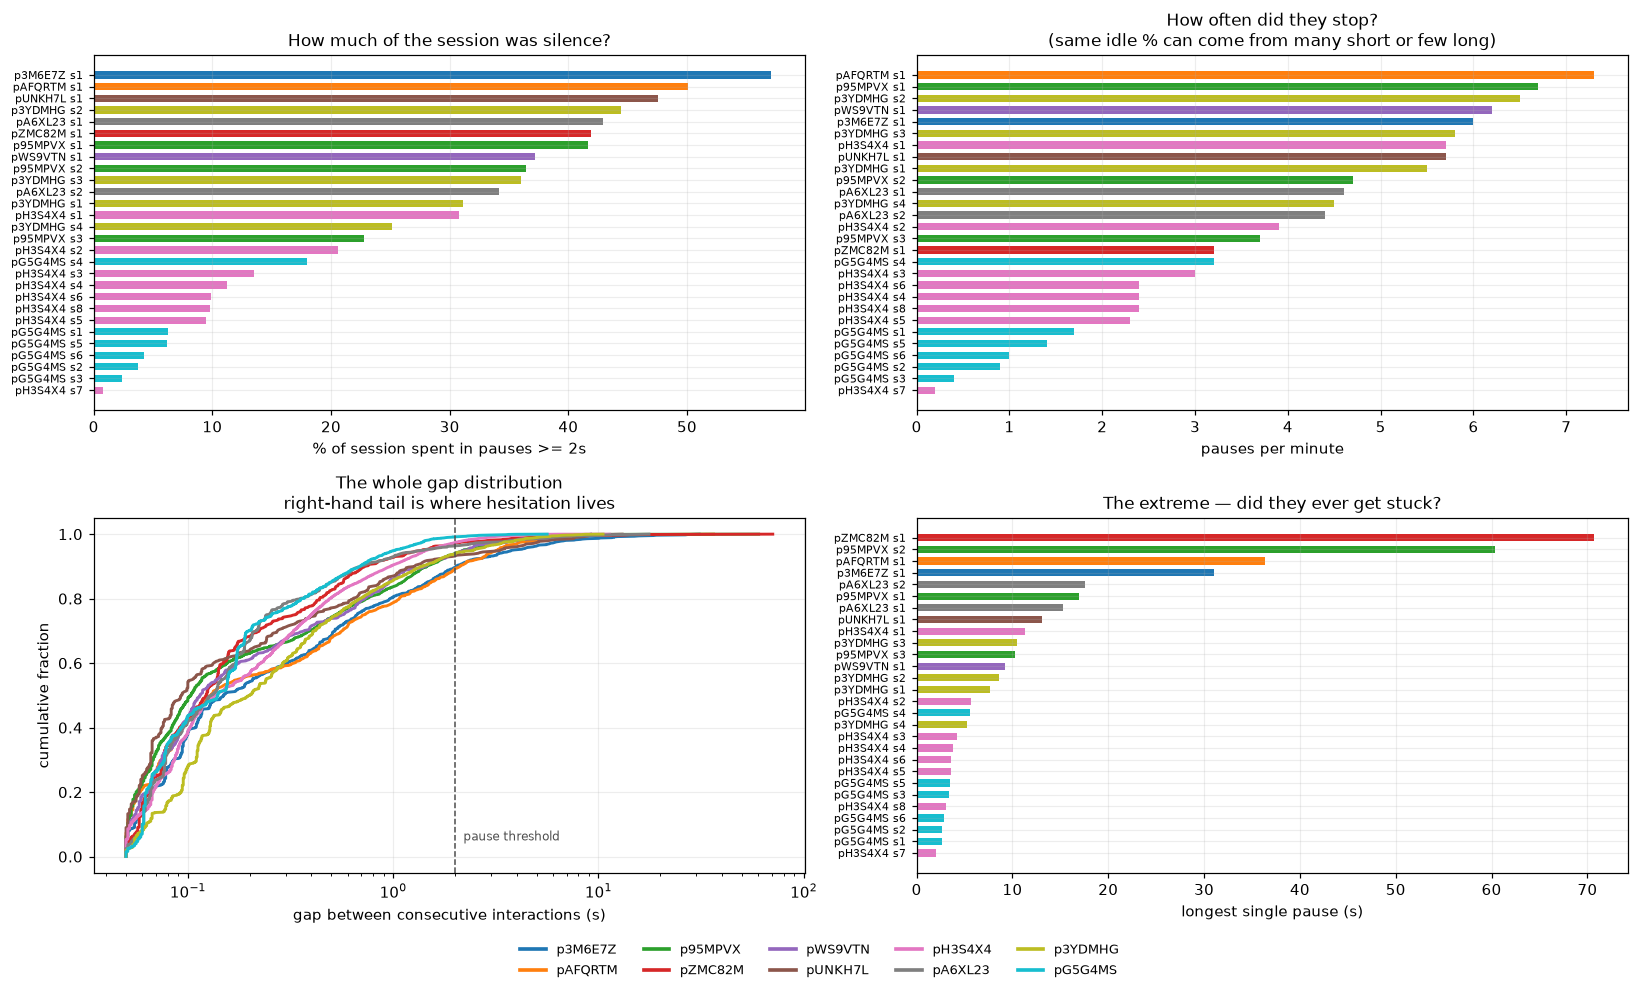

In [9]:
def plot_silence(silence, gap_store):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))

    ax = axes[0, 0]
    d = silence.sort_values('idle_pct')
    y = np.arange(len(d))
    ax.barh(y, d['idle_pct'], color=[pcolor(p) for p in d['p']], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=7)
    ax.set_xlabel("% of session spent in pauses >= 2s")
    ax.set_title("How much of the session was silence?")

    ax = axes[0, 1]
    d2 = silence.sort_values('pauses_per_min')
    y = np.arange(len(d2))
    ax.barh(y, d2['pauses_per_min'], color=[pcolor(p) for p in d2['p']], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d2['session'], fontsize=7)
    ax.set_xlabel("pauses per minute")
    ax.set_title("How often did they stop?\n(same idle % can come from many short or few long)")

    ax = axes[1, 0]
    for p in PARTICIPANTS:
        allg = np.concatenate([gap_store[sid] for sid in
                               session_index.loc[session_index['participantId'] == p, 'sessionId']
                               if sid in gap_store] or [np.array([])])
        allg = allg[allg > 0.05]
        if len(allg) < 20:
            continue
        allg = np.sort(allg)
        ax.plot(allg, np.arange(1, len(allg) + 1) / len(allg), color=pcolor(p), lw=1.9)
    ax.axvline(IDLE_GAP_S, color='0.3', ls='--', lw=1)
    ax.text(IDLE_GAP_S * 1.1, 0.05, 'pause threshold', fontsize=8, color='0.3')
    ax.set_xscale('log'); ax.set_xlabel("gap between consecutive interactions (s)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("The whole gap distribution\nright-hand tail is where hesitation lives")

    ax = axes[1, 1]
    d3 = silence.sort_values('longest_pause_s')
    y = np.arange(len(d3))
    ax.barh(y, d3['longest_pause_s'], color=[pcolor(p) for p in d3['p']], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d3['session'], fontsize=7)
    ax.set_xlabel("longest single pause (s)")
    ax.set_title("The extreme — did they ever get stuck?")

    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    plt.tight_layout(rect=[0, 0.045, 1, 1]); plt.show(); plt.close(fig)


plot_silence(silence, gap_store)

## 7. Bursts — rhythm above the level of single events

Interactions arrive in clusters, not evenly. A scroll gesture is a dozen scroll events over
half a second; a typed word is a run of keystrokes. The **burst** is the natural unit one
level up from the individual event, and it has its own rhythm with three independent parts:

- **burst size** — how many events per cluster (a long swipe vs a short flick)
- **burst duration** — how long the cluster lasts
- **inter-burst gap** — how long between clusters (the thinking time between actions)

Someone who scrolls in many short pecks and someone who scrolls in a few long pushes can
produce identical total scroll counts. The burst view separates them; an event-count rate
cannot.

Scroll bursts (a burst = scroll events separated by < 300ms):

participant  n_bursts  median_size  median_duration_ms  median_gap_ms
    p3M6E7Z       142          8.0               250.0         2237.0
    pAFQRTM        97         12.0               437.0         4730.0
    p95MPVX       347         11.0               390.0         2589.0
    pZMC82M       108          4.0               108.0         2028.0
    pWS9VTN        97          7.0               257.0         3047.0
    pUNKH7L        69         10.0               334.0         2513.0
    pH3S4X4      1297         12.0               403.0         1489.0
    pA6XL23       216          6.0               197.0         1373.0
    p3YDMHG       228          7.0               207.0         3703.0
    pG5G4MS       273          5.0               133.0         2171.0


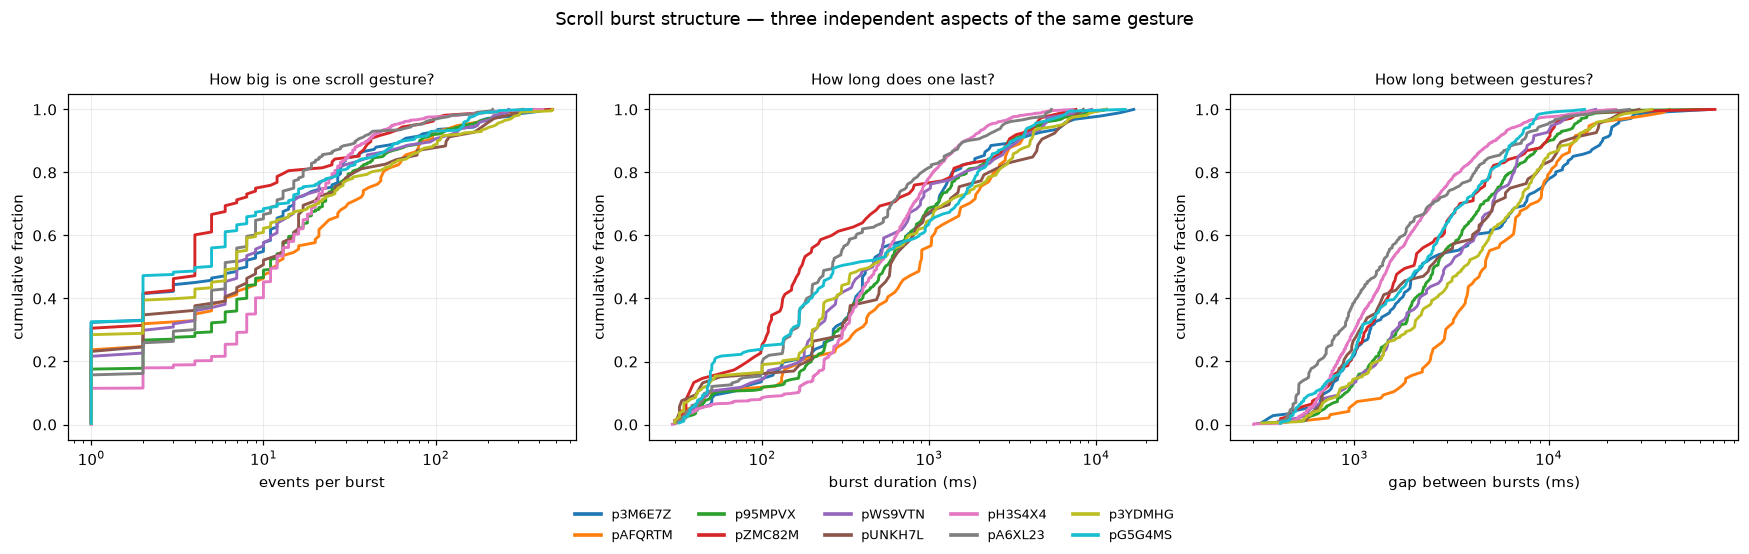

In [10]:
BURST_GAP_MS = 300.0


def burst_stats(sess, kinds, gap_ms=BURST_GAP_MS):
    t = ev_times(sess, kinds) * 1000.0
    if len(t) == 0:
        return pd.DataFrame(columns=['size', 'duration_ms', 'gap_ms'])
    brk = np.where(np.diff(t) > gap_ms)[0]
    groups = np.split(t, brk + 1)
    sizes = np.array([len(g) for g in groups], float)
    durs = np.array([g[-1] - g[0] for g in groups], float)
    starts = np.array([g[0] for g in groups])
    gaps = np.concatenate([[np.nan], np.diff(starts)])
    return pd.DataFrame({'size': sizes, 'duration_ms': durs, 'gap_ms': gaps})


burst_frames = {}
rows = []
for p in PARTICIPANTS:
    frames = []
    for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
        b = burst_stats(raw.loc[raw['sessionId'] == sid], SCROLL_KINDS)
        if len(b):
            frames.append(b)
    if frames:
        d = pd.concat(frames, ignore_index=True)
        burst_frames[p] = d
        rows.append({'participant': p, 'n_bursts': len(d),
                     'median_size': d['size'].median(),
                     'median_duration_ms': d['duration_ms'].median(),
                     'median_gap_ms': d['gap_ms'].median()})
burst_summary = pd.DataFrame(rows)
print("Scroll bursts (a burst = scroll events separated by < 300ms):\n")
print(burst_summary.round(0).to_string(index=False))


def plot_bursts(burst_frames, burst_summary):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    panels = [('size', 'events per burst', 'How big is one scroll gesture?'),
              ('duration_ms', 'burst duration (ms)', 'How long does one last?'),
              ('gap_ms', 'gap between bursts (ms)', 'How long between gestures?')]
    for ax, (col, xlab, title) in zip(axes, panels):
        for p, d in burst_frames.items():
            v = d[col].dropna().to_numpy()
            v = v[v > 0]
            if len(v) < 15:
                continue
            v = np.sort(v)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xscale('log'); ax.set_xlabel(xlab); ax.set_ylabel("cumulative fraction")
        ax.set_title(title, fontsize=10)
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in burst_frames]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    fig.suptitle("Scroll burst structure — three independent aspects of the same gesture", y=1.02)
    plt.tight_layout(rect=[0, 0.08, 1, 1]); plt.show(); plt.close(fig)


plot_bursts(burst_frames, burst_summary)

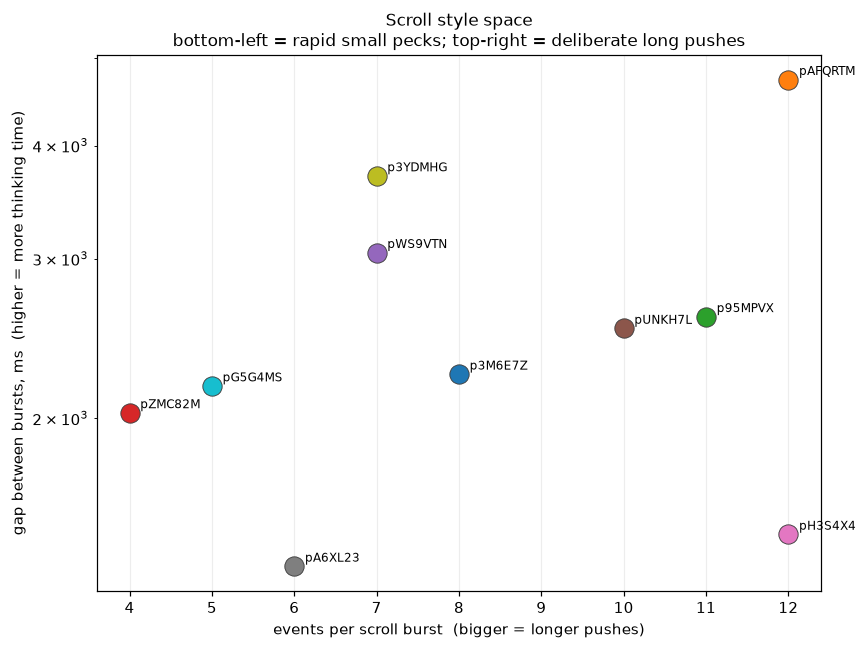

In [11]:
def plot_burst_space(burst_summary):
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, r in burst_summary.iterrows():
        ax.scatter(r['median_size'], r['median_gap_ms'], s=160, color=pcolor(r['participant']),
                   edgecolor='0.25', lw=0.6, zorder=3)
        ax.annotate(r['participant'], (r['median_size'], r['median_gap_ms']),
                    fontsize=8, xytext=(7, 3), textcoords='offset points')
    ax.set_xlabel("events per scroll burst  (bigger = longer pushes)")
    ax.set_ylabel("gap between bursts, ms  (higher = more thinking time)")
    ax.set_yscale('log')
    ax.set_title("Scroll style space\n"
                 "bottom-left = rapid small pecks; top-right = deliberate long pushes")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_burst_space(burst_summary)

## 8. Regularity — metronomic or erratic

Everything so far measures *how fast*. Regularity is independent of that: it asks how
**consistent** the intervals are. Two people with the same median inter-tap interval can be
completely different — one machine-like, the other alternating between rapid bursts and long
hesitations.

Two complementary measures, because they capture different things:

- **Coefficient of variation (CV)** — spread of all intervals divided by their mean. A global
  measure: is this person's rhythm tight or loose overall? Scale-free, so a slow-but-steady
  person and a fast-but-steady person both score low.
- **Local variation (CV2)** — compares each interval only with its immediate neighbour,
  averaged over the session. This is deliberately insensitive to slow drift: someone who
  gradually speeds up across a session has a high global CV but can still have low local
  variation, because each interval resembles the one before it.

The pair separates *"erratic moment to moment"* from *"changed pace over the session"*, which
a single number cannot.

Regularity. CV_global is inflated by drift across a session; CV2_local is not.

               interval participant  n_sessions  median_interval_ms  CV_global  CV2_local
              inter-tap     p3M6E7Z           1             2531.00       1.19       0.86
              inter-tap     pAFQRTM           1             2403.50       1.20       0.73
              inter-tap     p95MPVX           3             1782.50       0.96       0.69
              inter-tap     pZMC82M           1              562.00       3.03       0.58
              inter-tap     pWS9VTN           1             1264.50       1.07       0.72
              inter-tap     pUNKH7L           1             1533.00       0.97       0.79
              inter-tap     pH3S4X4           8             1246.25       1.16       0.58
              inter-tap     pA6XL23           2              658.00       1.44       0.61
              inter-tap     p3YDMHG           4             1764.50       1.18       0.81
              inter-

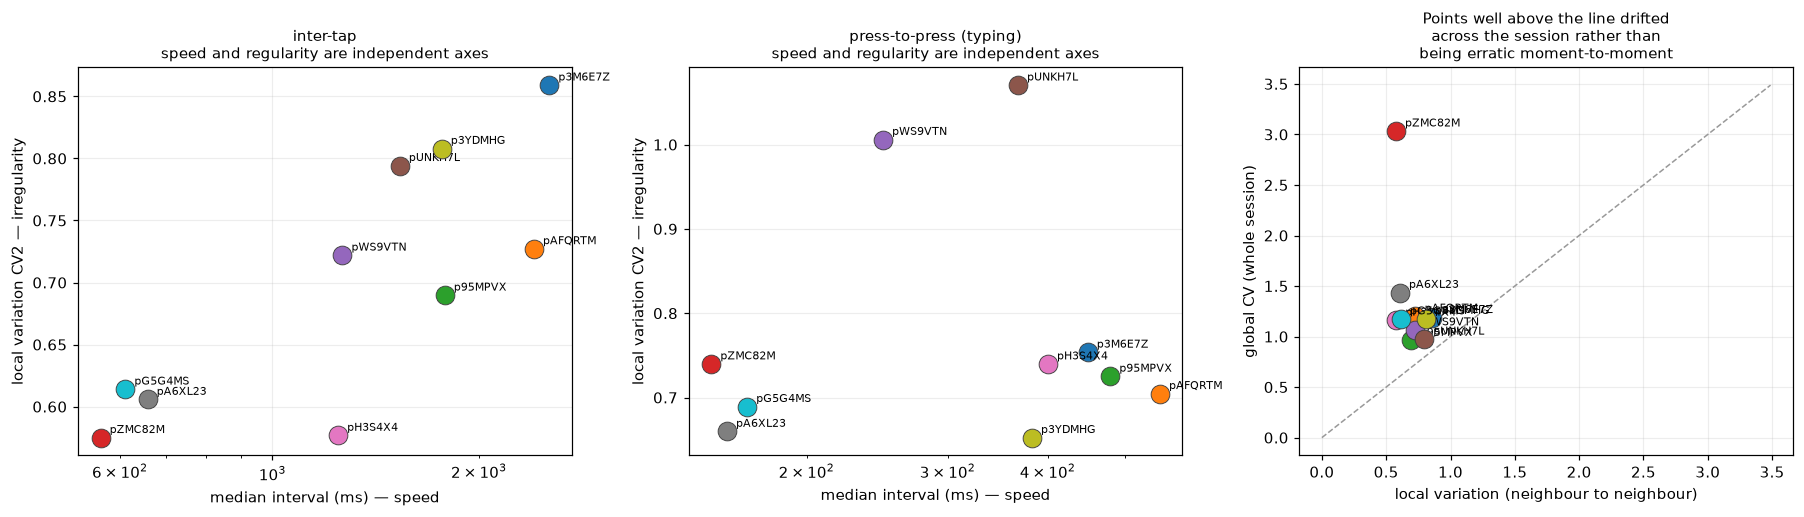

In [12]:
def cv_global(v):
    v = v[np.isfinite(v) & (v > 0)]
    return float(np.std(v) / np.mean(v)) if len(v) > 5 and np.mean(v) > 0 else np.nan


def cv2_local(v):
    # mean of 2|I(n+1)-I(n)| / (I(n+1)+I(n)) -- compares neighbours only,
    # so slow drift across a session does not inflate it
    v = v[np.isfinite(v) & (v > 0)]
    if len(v) < 6:
        return np.nan
    a, b = v[:-1], v[1:]
    return float(np.mean(2 * np.abs(b - a) / (a + b)))


reg_rows = []
for name in ['inter-tap', 'press-to-press (typing)']:
    for p in PARTICIPANTS:
        per_session = []
        for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
            v = INTERVAL_DEFS[name](raw.loc[raw['sessionId'] == sid])
            v = v[np.isfinite(v) & (v > 0)]
            if len(v) >= 10:
                per_session.append((cv_global(v), cv2_local(v), np.median(v)))
        if per_session:
            arr = np.array(per_session)
            reg_rows.append({'interval': name, 'participant': p, 'n_sessions': len(arr),
                             'median_interval_ms': np.nanmedian(arr[:, 2]),
                             'CV_global': np.nanmedian(arr[:, 0]),
                             'CV2_local': np.nanmedian(arr[:, 1])})
reg = pd.DataFrame(reg_rows)
print("Regularity. CV_global is inflated by drift across a session; CV2_local is not.\n")
print(reg.round(2).to_string(index=False))


def plot_regularity(reg):
    names = reg['interval'].unique()
    fig, axes = plt.subplots(1, len(names) + 1, figsize=(16.5, 4.8))
    for ax, name in zip(axes, names):
        d = reg.loc[reg['interval'] == name]
        for _, r in d.iterrows():
            ax.scatter(r['median_interval_ms'], r['CV2_local'], s=150,
                       color=pcolor(r['participant']), edgecolor='0.25', lw=0.6, zorder=3)
            ax.annotate(r['participant'], (r['median_interval_ms'], r['CV2_local']),
                        fontsize=7.5, xytext=(6, 3), textcoords='offset points')
        ax.set_xscale('log')
        ax.set_xlabel("median interval (ms) — speed")
        ax.set_ylabel("local variation CV2 — irregularity")
        ax.set_title(f"{name}\nspeed and regularity are independent axes", fontsize=9.5)

    ax = axes[-1]
    d = reg.loc[reg['interval'] == names[0]]
    for _, r in d.iterrows():
        ax.scatter(r['CV2_local'], r['CV_global'], s=150, color=pcolor(r['participant']),
                   edgecolor='0.25', lw=0.6, zorder=3)
        ax.annotate(r['participant'], (r['CV2_local'], r['CV_global']),
                    fontsize=7.5, xytext=(6, 3), textcoords='offset points')
    lim = [0, max(d['CV_global'].max(), d['CV2_local'].max()) * 1.15]
    ax.plot(lim, lim, ls='--', color='0.6', lw=1)
    ax.set_xlabel("local variation (neighbour to neighbour)")
    ax.set_ylabel("global CV (whole session)")
    ax.set_title("Points well above the line drifted\nacross the session rather than\n"
                 "being erratic moment-to-moment", fontsize=9.5)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_regularity(reg)

## 9. Rhythm over session time — drift, practice, fatigue

All of the above collapses a session to one number. This section keeps time on the x-axis and
asks whether rhythm is *stable within* a session.

Three things can happen, and they look different:

- **Practice** — speeding up as the interface becomes familiar. Tasks 3-13 repeat as 14-24,
  so there is a built-in second pass to compare against.
- **Fatigue** — slowing down, or becoming more erratic, late in a session.
- **Stall** — one long interruption in an otherwise steady session.

Each faint line is a session; the bold line is that participant's median across sessions.

/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_10109/3168168494.py:33: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(np.vstack(stack), axis=0)


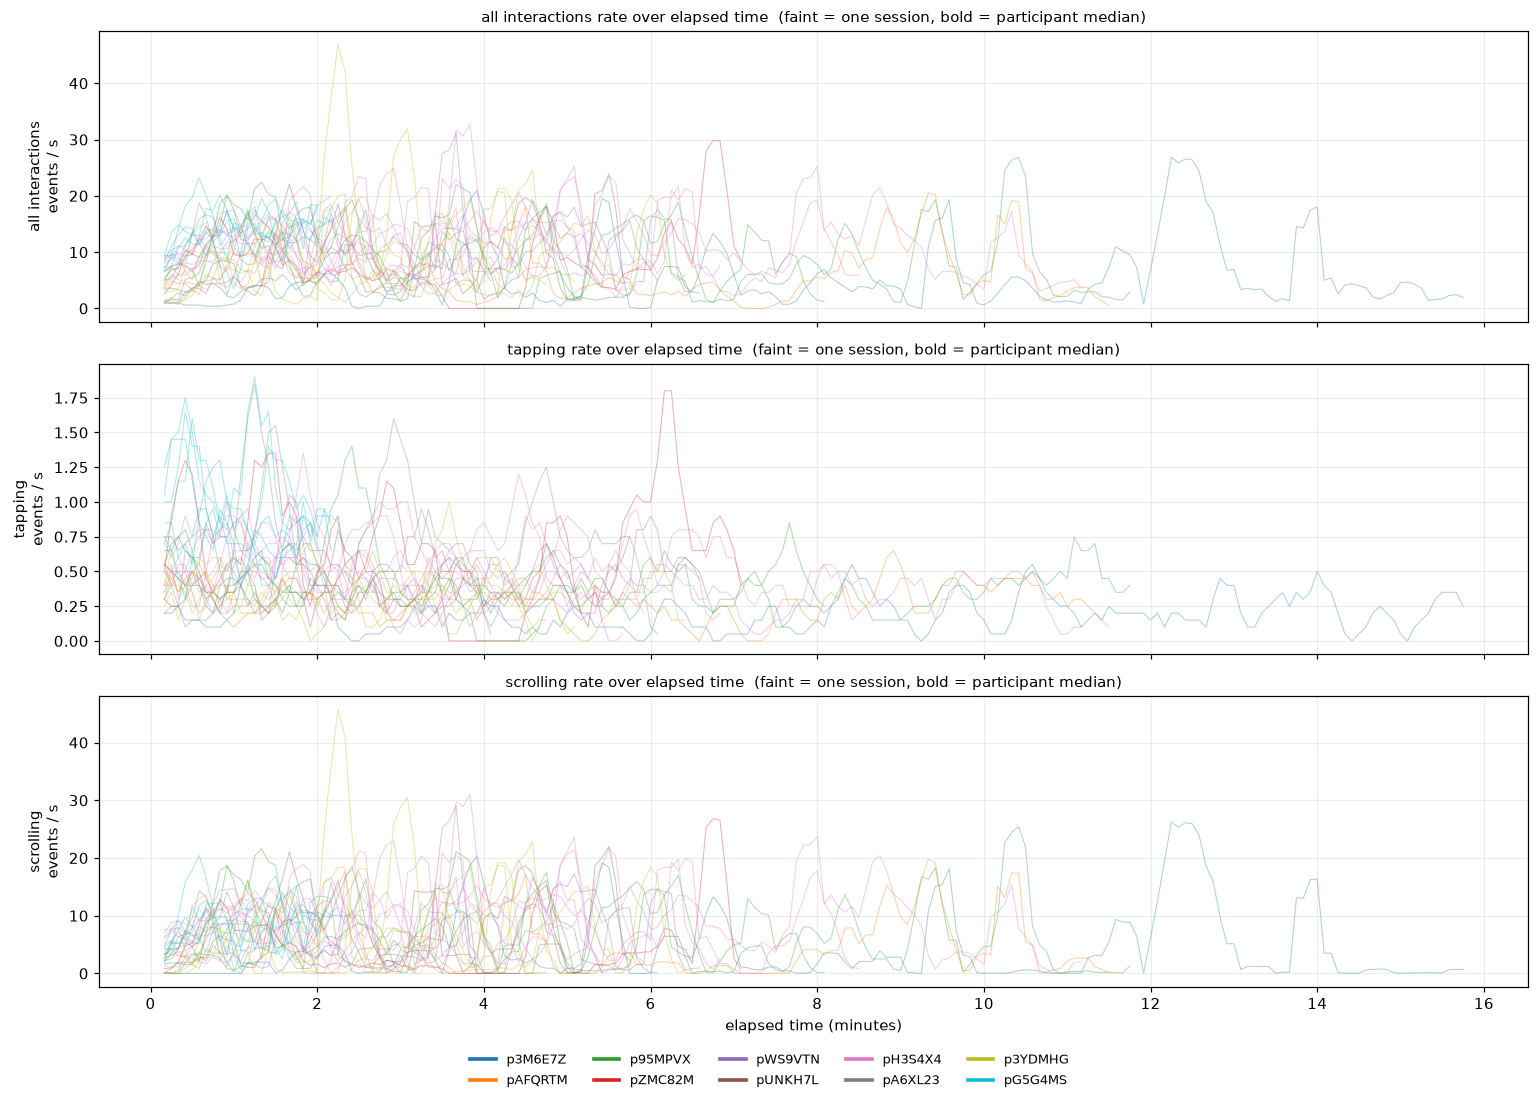

In [13]:
WIN_S, STRIDE_S = 20.0, 5.0     # wider than the 7.5s operational window: at 7.5s the
                                # per-window event counts are too small for a stable rate


def windowed_rate(sess, kinds, win_s=WIN_S, stride_s=STRIDE_S):
    t = ev_times(sess, kinds)
    end = sess['tRelMs'].max() / 1000.0
    centres, rates = [], []
    lo = 0.0
    while lo + win_s <= end:
        n = np.sum((t >= lo) & (t < lo + win_s))
        centres.append(lo + win_s / 2); rates.append(n / win_s)
        lo += stride_s
    return np.array(centres), np.array(rates)


def plot_rhythm_over_time(raw_df):
    panels = [('all interactions', INTERACTION_KINDS), ('tapping', [TAP_DOWN]),
              ('scrolling', SCROLL_KINDS)]
    fig, axes = plt.subplots(len(panels), 1, figsize=(14, 10), sharex=True)
    for ax, (name, kinds) in zip(axes, panels):
        for p in PARTICIPANTS:
            curves = []
            for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
                c, r = windowed_rate(raw_df.loc[raw_df['sessionId'] == sid], kinds)
                if len(c) < 3:
                    continue
                ax.plot(c / 60, r, color=pcolor(p), lw=0.7, alpha=0.35)
                curves.append((c / 60, r))
            if curves:
                grid = np.arange(0, max(c[-1] / 60 for c, _ in curves) + 0.5, 0.5)
                stack = [np.interp(grid, c, r, left=np.nan, right=np.nan) for c, r in curves]
                med = np.nanmedian(np.vstack(stack), axis=0)
                ax.plot(grid, med, color=pcolor(p), lw=2.6)
        ax.set_ylabel(f"{name}\nevents / s")
        ax.set_title(f"{name} rate over elapsed time  (faint = one session, bold = participant median)",
                     fontsize=9.5)
    axes[-1].set_xlabel("elapsed time (minutes)")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show(); plt.close(fig)


plot_rhythm_over_time(raw)

Median speed-up on the repeated pass (tasks _01 vs _02), per participant:
participantId
p3M6E7Z    65.2
pAFQRTM    24.7
p95MPVX    19.6
pZMC82M    30.3
pWS9VTN    23.9
pUNKH7L    24.5
pH3S4X4     9.1
pA6XL23    34.9
p3YDMHG    21.2
pG5G4MS     5.3


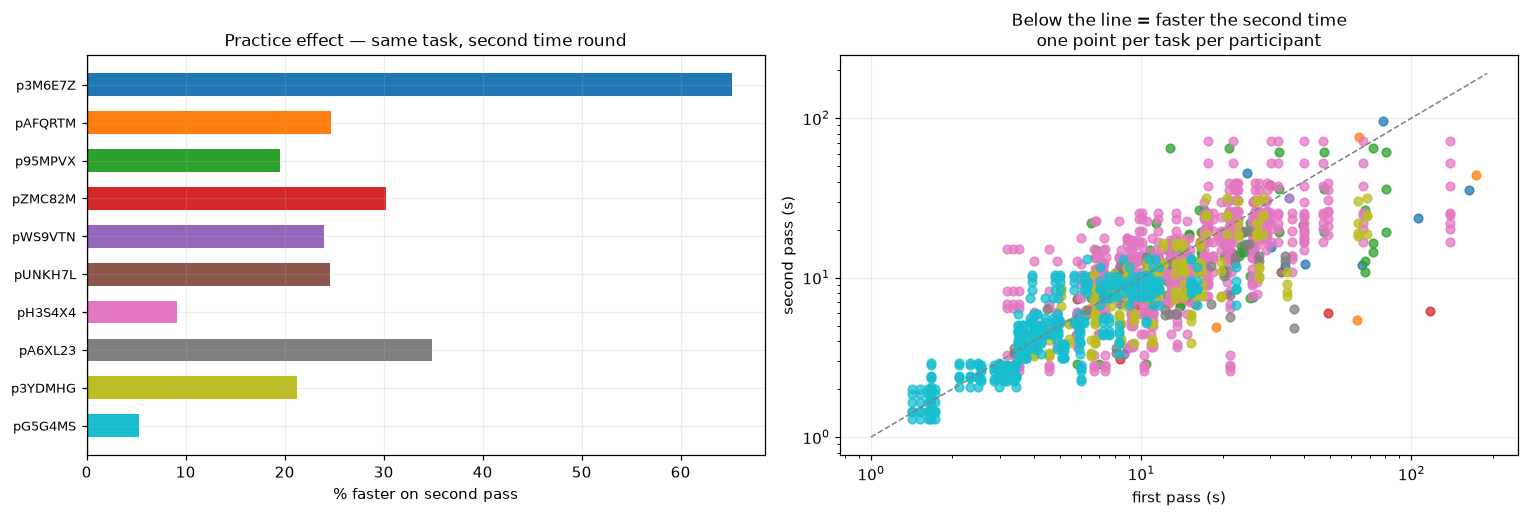

In [14]:
# tasks 3-13 repeat as 14-24: a built-in first-pass vs second-pass comparison
def pass_comparison(raw_df):
    tl = timeline.copy()
    tl['dur_s'] = tl['t_end_s'] - tl['t_start_s']
    tl = tl.merge(session_index[['sessionId', 'participantId']], on='sessionId', how='left')
    tl['base'] = tl['taskId'].str.replace(r'_0\d$', '', regex=True)
    first = tl.loc[tl['taskId'].str.endswith('_01'), ['participantId', 'base', 'dur_s']]
    second = tl.loc[tl['taskId'].str.endswith('_02'), ['participantId', 'base', 'dur_s']]
    m = first.merge(second, on=['participantId', 'base'], suffixes=('_1st', '_2nd'))
    m['speedup_pct'] = 100 * (1 - m['dur_s_2nd'] / m['dur_s_1st'])
    return m


passes = pass_comparison(raw)
per_p = passes.groupby('participantId')['speedup_pct'].median().reindex(PARTICIPANTS).dropna()
print("Median speed-up on the repeated pass (tasks _01 vs _02), per participant:")
print(per_p.round(1).to_string())


def plot_practice(passes, per_p):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    ax = axes[0]
    y = np.arange(len(per_p))
    ax.barh(y, per_p.values, color=[pcolor(p) for p in per_p.index], height=0.6)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(per_p.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel("% faster on second pass")
    ax.set_title("Practice effect — same task, second time round")

    ax = axes[1]
    for p in PARTICIPANTS:
        d = passes.loc[passes['participantId'] == p]
        if len(d) < 3:
            continue
        ax.scatter(d['dur_s_1st'], d['dur_s_2nd'], color=pcolor(p), s=32, alpha=0.75)
    lim = [1, passes[['dur_s_1st', 'dur_s_2nd']].to_numpy().max() * 1.1]
    ax.plot(lim, lim, ls='--', color='0.5', lw=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("first pass (s)"); ax.set_ylabel("second pass (s)")
    ax.set_title("Below the line = faster the second time\none point per task per participant")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_practice(passes, per_p)

## 10. Task-entry latency — hesitation at a boundary

Every session has 26 task transitions at known timestamps. The gap between a task appearing
and the person's first interaction with it is a clean, repeated measurement of **orientation
time**: reading the screen, finding the control, deciding what to do.

This is different from the pauses in Section 6, which can happen anywhere. Task-entry latency
is anchored to a specific, identical moment in every session — 26 repeats per session,
520 across the cohort — which makes it one of the most directly comparable measurements
available here.

Time from a task appearing to the first interaction with it:

participant  n_transitions  median_ms  p90_ms  max_ms
    p3M6E7Z             26     5081.0 13329.0 31000.0
    pAFQRTM             26     2933.0  6428.0  7888.0
    p95MPVX             78     1114.0  3351.0 60356.0
    pZMC82M             26      669.0  4130.0  8029.0
    pWS9VTN             26      728.0  4650.0  8963.0
    pUNKH7L             26     1227.0  7224.0 13056.0
    pH3S4X4            208      962.0  2304.0  5953.0
    pA6XL23             52      593.0  5970.0 10953.0
    p3YDMHG            104     1700.0  4225.0  7661.0
    pG5G4MS            156      926.0  1900.0  5629.0


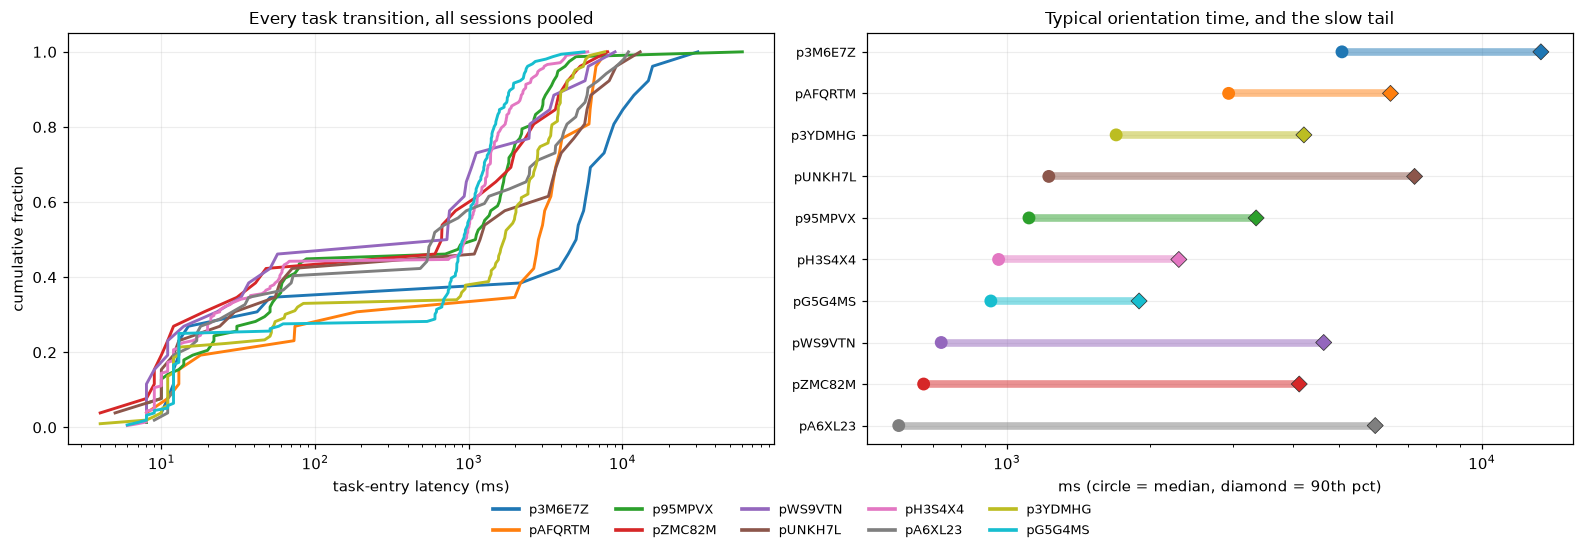

In [15]:
def entry_latencies(sess):
    starts = ev_times(sess, 'task_start')
    inter = ev_times(sess, INTERACTION_KINDS)
    out = []
    for t0 in starts:
        nxt = inter[inter >= t0]
        if len(nxt):
            out.append((nxt[0] - t0) * 1000.0)
    return np.array(out)


lat_store, rows = {}, []
for p in PARTICIPANTS:
    vals = []
    for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
        vals.append(entry_latencies(raw.loc[raw['sessionId'] == sid]))
    v = np.concatenate(vals) if vals else np.array([])
    lat_store[p] = v
    if len(v):
        rows.append({'participant': p, 'n_transitions': len(v),
                     'median_ms': np.median(v), 'p90_ms': np.percentile(v, 90),
                     'max_ms': v.max()})
lat_summary = pd.DataFrame(rows)
print("Time from a task appearing to the first interaction with it:\n")
print(lat_summary.round(0).to_string(index=False))


def plot_latency(lat_store, lat_summary):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
    ax = axes[0]
    for p, v in lat_store.items():
        v = np.sort(v[v > 0])
        if len(v) < 10:
            continue
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xscale('log'); ax.set_xlabel("task-entry latency (ms)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Every task transition, all sessions pooled")

    ax = axes[1]
    d = lat_summary.sort_values('median_ms')
    y = np.arange(len(d))
    ax.hlines(y, d['median_ms'], d['p90_ms'], color=[pcolor(p) for p in d['participant']],
              lw=5, alpha=0.5)
    ax.scatter(d['median_ms'], y, color=[pcolor(p) for p in d['participant']], s=55, zorder=3)
    ax.scatter(d['p90_ms'], y, color=[pcolor(p) for p in d['participant']], s=55,
               marker='D', edgecolor='0.2', lw=0.5, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(d['participant'], fontsize=8.5)
    ax.set_xscale('log'); ax.set_xlabel("ms (circle = median, diamond = 90th pct)")
    ax.set_title("Typical orientation time, and the slow tail")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show(); plt.close(fig)


plot_latency(lat_store, lat_summary)

## 11. Modality switching — how attention moves between channels

A different kind of rhythm: not the timing within one channel, but how a person moves
*between* them. Someone who types a little, taps, scrolls back, types again has a different
interaction texture from someone who completes each phase before moving on — even if their
per-channel timings are identical.

**A confound that has to be handled first, because it dominates the naive version of this
measurement.** A scroll gesture physically *begins* with a finger-down — the browser emits
`touchstart` and then a run of `scroll` events. Counting raw modality changes therefore
counts every scroll gesture as a tapping-to-scrolling "switch", which is mechanical, not
attentional. Measured directly: **64% of tapping-to-scrolling transitions occur within 300 ms**
of each other, and 40% within 100 ms — far too fast to be a decision.

The fix is to require a **dwell** before a change counts as a switch: the new modality must
hold for at least 500 ms before the transition is treated as real. Both versions are shown
below so the size of the correction is visible rather than hidden.

Modality switching, before and after the dwell filter.
'raw' counts every modality change; 'switches_per_min' requires the new modality
to hold for 0.5s, which removes the finger-down-starts-a-scroll artifact.

participant  raw_switches_per_min  switches_per_min  median_run_len  p90_run_len
    p3M6E7Z                 12.87              5.65             2.0         42.5
    pAFQRTM                 18.51              8.23             2.0         47.0
    p95MPVX                 26.08             11.48             2.0         44.6
    pZMC82M                 57.44              9.37             2.0          9.0
    pWS9VTN                 29.09             11.81             3.0         27.9
    pUNKH7L                 24.36             10.35             2.0         49.2
    pH3S4X4                 42.23             14.76             2.0         34.0
    pA6XL23                 59.70              9.53             2.0         12.0
    p3YDMHG                 23.03              9.19         

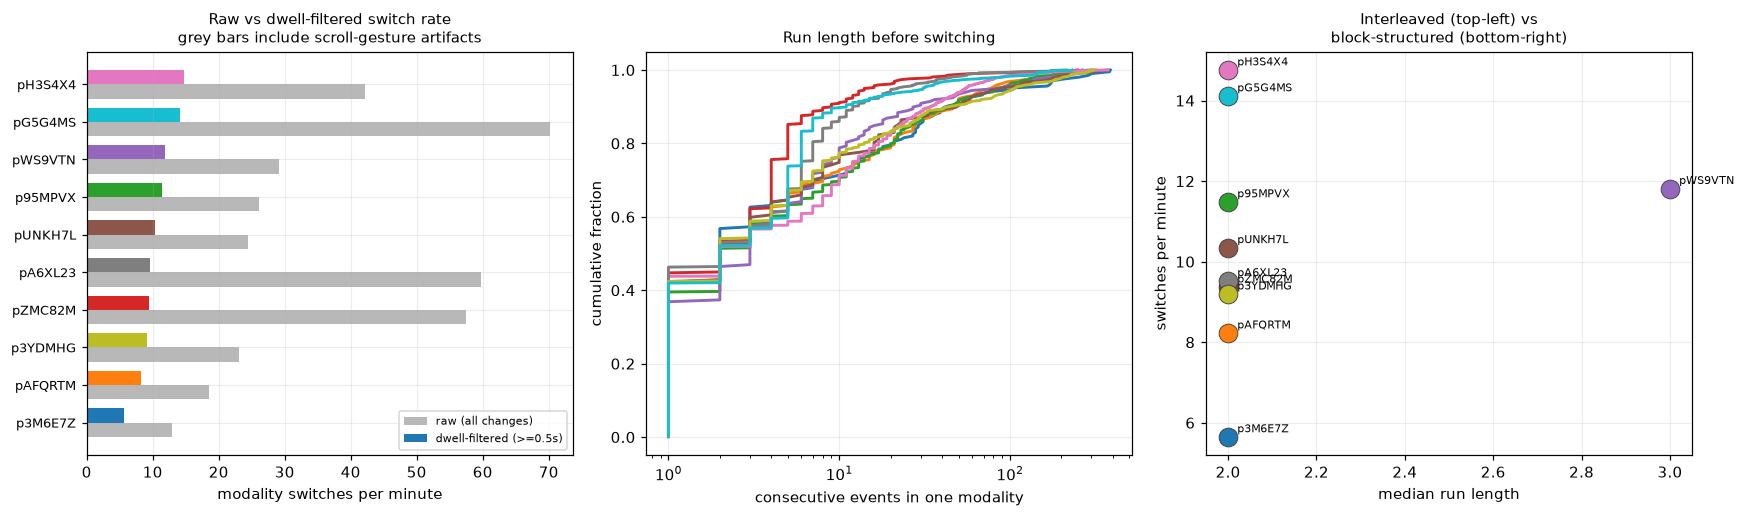

In [16]:
def modality_stream(sess):
    frames = []
    for mod, kinds in MODALITY_KINDS.items():
        t = ev_times(sess, kinds)
        if len(t):
            frames.append(pd.DataFrame({'t': t, 'mod': mod}))
    if not frames:
        return pd.DataFrame(columns=['t', 'mod'])
    return pd.concat(frames).sort_values('t').reset_index(drop=True)


SWITCH_DWELL_S = 0.5   # a modality must hold this long for the change to count as real


def switch_counts(sess):
    # returns (raw_switches, dwell_filtered_switches, run_lengths)
    st = modality_stream(sess)
    if len(st) < 5:
        return 0, 0, np.array([])
    chg = st['mod'].ne(st['mod'].shift())
    run_ids = chg.cumsum()
    runs = st.groupby(run_ids).size().to_numpy()
    # duration each run occupied, to apply the dwell rule
    run_t = st.groupby(run_ids)['t'].agg(['min', 'max'])
    span = (run_t['max'] - run_t['min']).to_numpy()
    # a run counts as a genuine destination if it lasted >= the dwell threshold
    real = int(np.sum(span >= SWITCH_DWELL_S)) - 1
    return max(int(chg.sum()) - 1, 0), max(real, 0), runs


rows, runlen_store = [], {}
for p in PARTICIPANTS:
    runs_all, sw_raw, sw_real, minutes = [], 0, 0, 0.0
    for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
        s = raw.loc[raw['sessionId'] == sid]
        a, b, runs = switch_counts(s)
        if len(runs) == 0:
            continue
        runs_all.append(runs); sw_raw += a; sw_real += b
        minutes += s['tRelMs'].max() / 60000.0
    if runs_all:
        runs = np.concatenate(runs_all)
        runlen_store[p] = runs
        rows.append({'participant': p,
                     'raw_switches_per_min': sw_raw / minutes if minutes else np.nan,
                     'switches_per_min': sw_real / minutes if minutes else np.nan,
                     'median_run_len': np.median(runs), 'p90_run_len': np.percentile(runs, 90)})
switch_summary = pd.DataFrame(rows)
print("Modality switching, before and after the dwell filter.")
print(f"'raw' counts every modality change; 'switches_per_min' requires the new modality")
print(f"to hold for {SWITCH_DWELL_S:.1f}s, which removes the finger-down-starts-a-scroll artifact.\n")
print(switch_summary.round(2).to_string(index=False))
_shrink = 100 * (1 - switch_summary['switches_per_min'] / switch_summary['raw_switches_per_min'])
print(f"\nthe filter removes {_shrink.min():.0f}-{_shrink.max():.0f}% of raw switches "
      f"depending on the participant -- note it does not remove a constant share, so the")
print("raw version is not simply a rescaled copy of the filtered one.")


def plot_switching(switch_summary, runlen_store):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    ax = axes[0]
    d = switch_summary.sort_values('switches_per_min')
    y = np.arange(len(d)); w = 0.38
    ax.barh(y - w / 2, d['raw_switches_per_min'], height=w, color='0.72', label='raw (all changes)')
    ax.barh(y + w / 2, d['switches_per_min'], height=w,
            color=[pcolor(p) for p in d['participant']], label=f'dwell-filtered (>={SWITCH_DWELL_S}s)')
    ax.set_yticks(y); ax.set_yticklabels(d['participant'], fontsize=8.5)
    ax.set_xlabel("modality switches per minute")
    ax.set_title("Raw vs dwell-filtered switch rate\ngrey bars include scroll-gesture artifacts",
                 fontsize=10)
    ax.legend(fontsize=7.5, loc='lower right')

    ax = axes[1]
    for p, r in runlen_store.items():
        r = np.sort(r[r > 0])
        if len(r) < 15:
            continue
        ax.plot(r, np.arange(1, len(r) + 1) / len(r), color=pcolor(p), lw=1.9)
    ax.set_xscale('log'); ax.set_xlabel("consecutive events in one modality")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Run length before switching", fontsize=10)

    ax = axes[2]
    for _, r in switch_summary.iterrows():
        ax.scatter(r["median_run_len"], r["switches_per_min"], s=150,
                   color=pcolor(r['participant']), edgecolor='0.25', lw=0.6, zorder=3)
        ax.annotate(r['participant'], (r['median_run_len'], r['switches_per_min']),
                    fontsize=7.5, xytext=(6, 3), textcoords='offset points')
    ax.set_xlabel("median run length"); ax.set_ylabel("switches per minute")
    ax.set_title("Interleaved (top-left) vs\nblock-structured (bottom-right)", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_switching(switch_summary, runlen_store)

## 12. Durations — how long events last, and the dwell trap

Duration is different from interval: it measures a *single* event's length rather than the
gap between two. Two are available:

- **Touch hold** — `touchstart` to `touchend`. How long a finger rests on the glass. This is
  a real motor measurement: a deliberate press versus a glancing tap.
- **Key dwell** — `keydown` to `keyup`. On a physical keyboard this measures key travel and
  finger pressure. **On a touchscreen it does not.**

The dwell trap is worth understanding properly, because it is the clearest example in this
project of a feature that looks alive and is not. On a touchscreen there is no key travel —
`keyup` follows `keydown` as fast as the browser can dispatch the pair. What gets measured is
event-loop latency, not a finger.

The panels below put the two side by side. Touch hold separates people; dwell largely does not.

Touch hold spans a wide range across people; key dwell clusters near a constant.

participant  n_holds  hold_median_ms  n_dwells  dwell_median_ms
    p3M6E7Z      189           109.0       165             10.0
    pAFQRTM      190           121.5       126             15.0
    p95MPVX      594           116.5       100             15.0
    pZMC82M      282           191.0       182             13.0
    pWS9VTN      188            99.5        42             15.5
    pUNKH7L      136            76.0        19             19.0
    pH3S4X4     1462           388.0       929             15.0
    pA6XL23      404           244.0       283             10.0
    p3YDMHG      459           128.0       513             10.0
    pG5G4MS      729           109.0       691             10.0


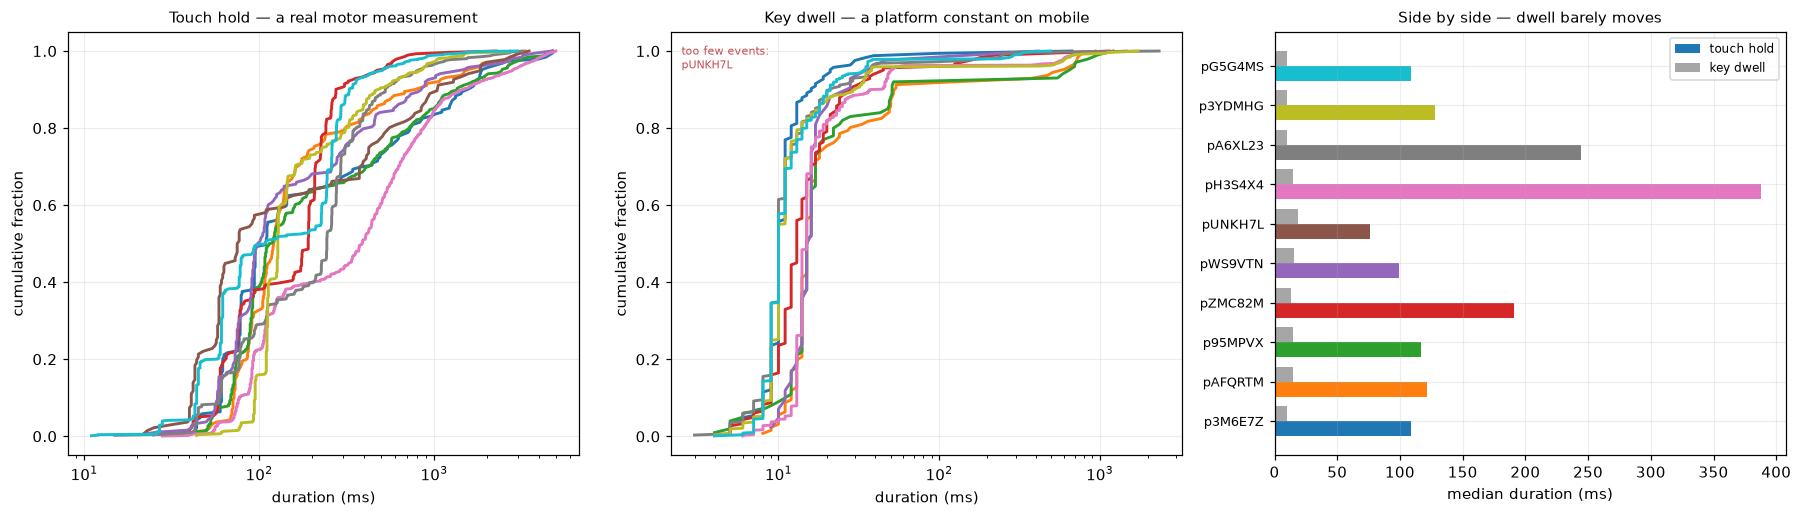

In [17]:
def paired_durations(sess, down_kind, up_kind):
    d = ev_times(sess, down_kind); u = ev_times(sess, up_kind)
    if len(d) == 0 or len(u) == 0:
        return np.array([])
    out = []
    for t0 in d:
        nxt = u[u > t0]
        if len(nxt):
            out.append((nxt[0] - t0) * 1000.0)
    return np.array(out)


hold_store, dwell_store, rows = {}, {}, []
for p in PARTICIPANTS:
    h, k = [], []
    for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
        s = raw.loc[raw['sessionId'] == sid]
        h.append(paired_durations(s, TAP_DOWN, TAP_UP))
        k.append(paired_durations(s, KEY_DOWN, KEY_UP))
    h = np.concatenate(h) if h else np.array([])
    k = np.concatenate(k) if k else np.array([])
    h = h[(h > 0) & (h < 5000)]; k = k[(k > 0) & (k < 5000)]
    hold_store[p], dwell_store[p] = h, k
    rows.append({'participant': p,
                 'n_holds': len(h), 'hold_median_ms': np.median(h) if len(h) else np.nan,
                 'n_dwells': len(k), 'dwell_median_ms': np.median(k) if len(k) else np.nan})
dur_summary = pd.DataFrame(rows)
print("Touch hold spans a wide range across people; key dwell clusters near a constant.\n")
print(dur_summary.round(1).to_string(index=False))


def plot_durations(hold_store, dwell_store, dur_summary):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    for ax, store, title in [(axes[0], hold_store, "Touch hold — a real motor measurement"),
                             (axes[1], dwell_store, "Key dwell — a platform constant on mobile")]:
        thin = []
        for p, v in store.items():
            v = np.sort(v)
            if len(v) < 20:
                thin.append(p); continue
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xscale('log'); ax.set_xlabel("duration (ms)"); ax.set_ylabel("cumulative fraction")
        ax.set_title(title, fontsize=10)
        if thin:
            ax.text(0.02, 0.97, "too few events:\n" + ", ".join(thin), transform=ax.transAxes,
                    va='top', fontsize=7.5, color='#c44e52')

    ax = axes[2]
    d = dur_summary.dropna(subset=['hold_median_ms', 'dwell_median_ms'])
    y = np.arange(len(d)); w = 0.38
    ax.barh(y - w / 2, d['hold_median_ms'], height=w, color=[pcolor(p) for p in d['participant']],
            label='touch hold')
    ax.barh(y + w / 2, d['dwell_median_ms'], height=w, color='0.65', label='key dwell')
    ax.set_yticks(y); ax.set_yticklabels(d['participant'], fontsize=8.5)
    ax.set_xlabel("median duration (ms)")
    ax.set_title("Side by side — dwell barely moves", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_durations(hold_store, dwell_store, dur_summary)

**The nuance worth keeping.** Dwell is not worthless — it is worthless for *pace*. Look at
whether any single participant's dwell curve sits apart from the pack even while the rest
overlap. A feature can carry a little identity and no tempo at all, and the two are separate
questions. What this does establish is that "does it vary?" is the wrong test for whether a
feature is alive: dwell takes many distinct values within every session and still lands on
top of everyone else's distribution.

## 13. Distribution shape — why medians lie

Every summary so far reduced a distribution to one or two numbers. This section shows what
that discards.

A median says where the middle is. It says nothing about whether the distribution is a tight
single peak, a long-tailed hesitation profile, or genuinely **bimodal** — two distinct modes
of behaviour mixed in one session. Bimodality matters most: it usually means the person is
doing two different things (fast automatic actions plus slow deliberate ones) and averaging
across them describes neither.

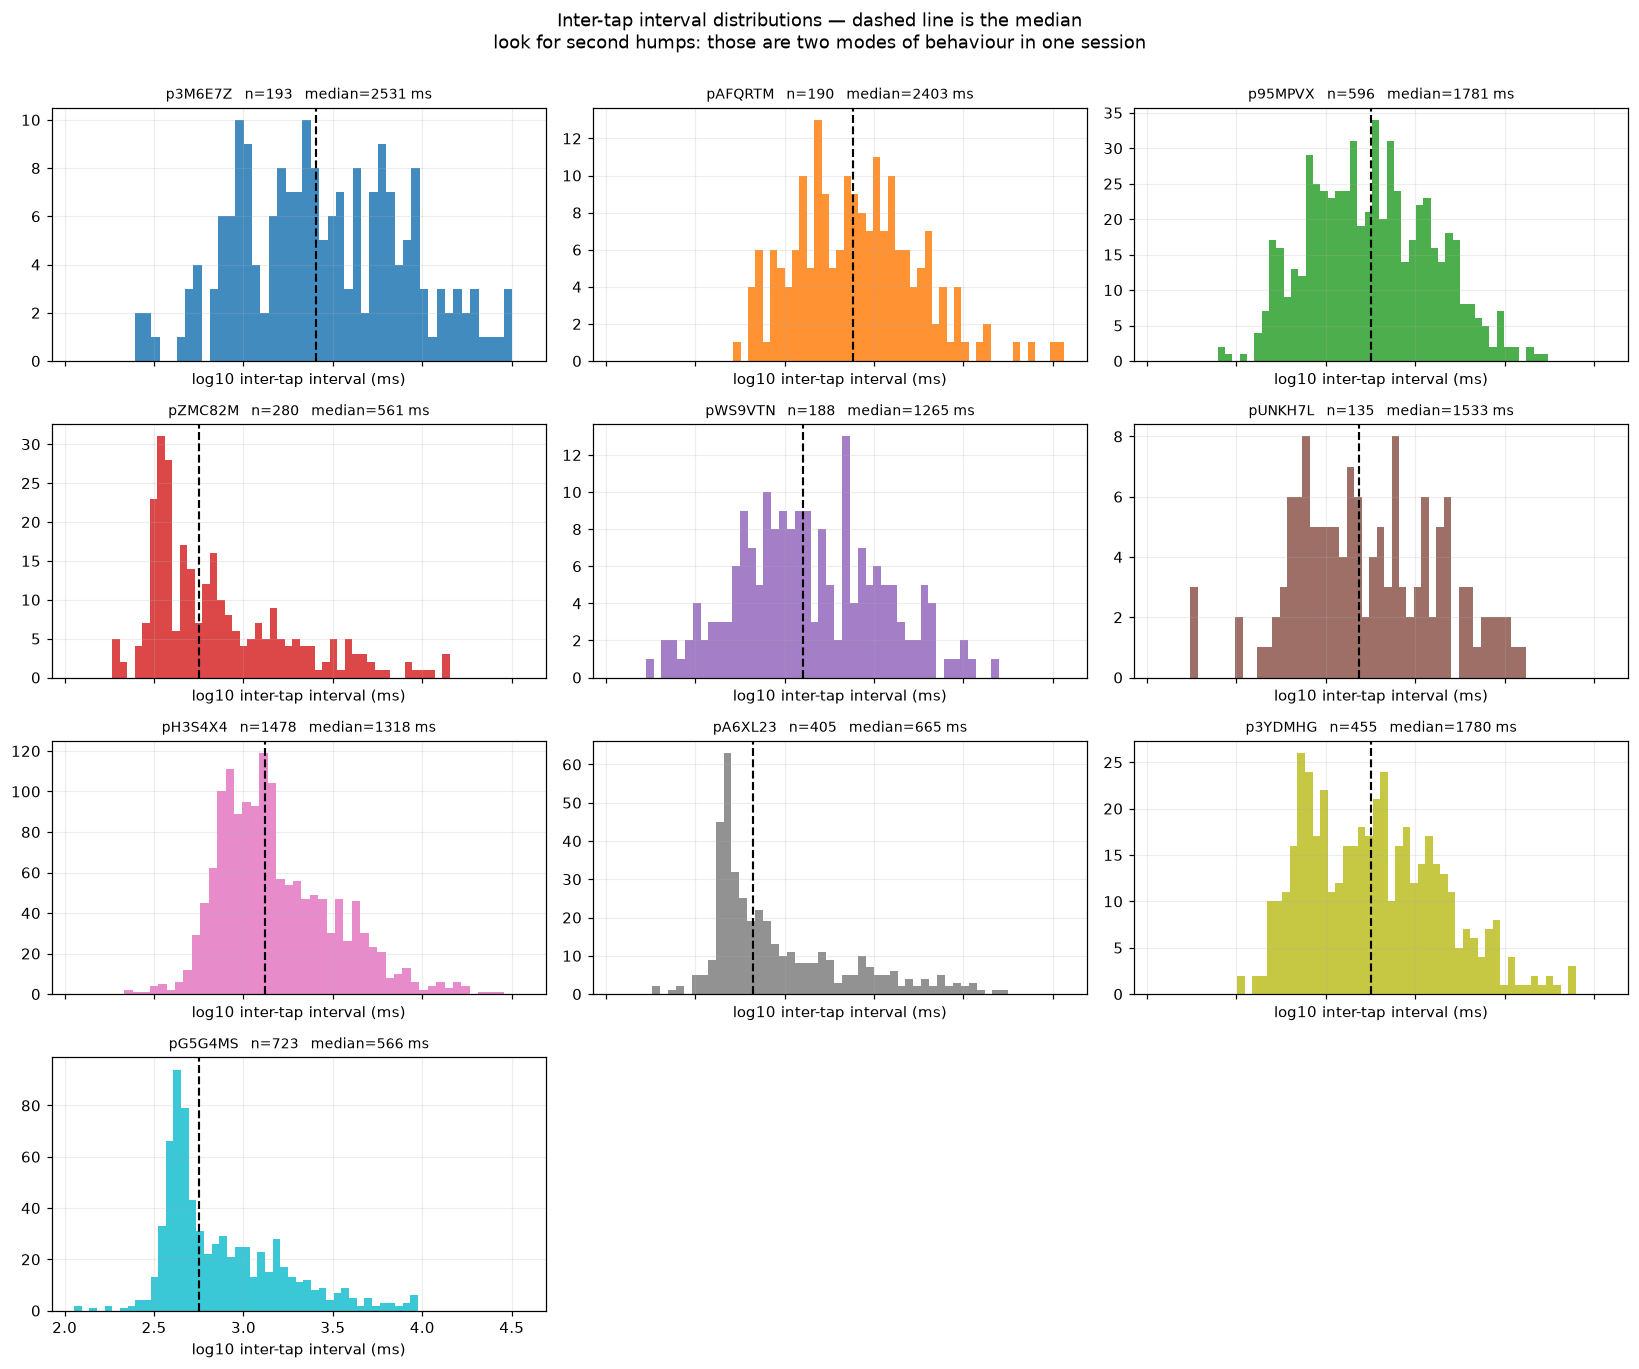

In [18]:
def plot_shape(IV):
    name = 'inter-tap'
    per_p = IV[name]
    have = [p for p in PARTICIPANTS if len(per_p[p]) >= 40]
    n = len(have)
    ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3.1 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, p in zip(axes, have):
        v = per_p[p]; v = v[(v > 0) & (v < 60000)]
        lv = np.log10(v)
        ax.hist(lv, bins=45, color=pcolor(p), alpha=0.85)
        ax.axvline(np.log10(np.median(v)), color='k', ls='--', lw=1.4)
        ax.set_title(f"{p}   n={len(v)}   median={np.median(v):.0f} ms", fontsize=9)
        ax.set_xlabel("log10 inter-tap interval (ms)")
    for ax in axes[len(have):]:
        ax.axis('off')
    fig.suptitle("Inter-tap interval distributions — dashed line is the median\n"
                 "look for second humps: those are two modes of behaviour in one session", y=1.0)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_shape(IV)

## 14. Per-modality rhythm side by side

The same rhythm question asked separately of the three channels, so a modality-specific model
has something to be designed against. The channels are not interchangeable: typing rhythm is
constrained by language production, tapping by spatial search, scrolling by reading speed.

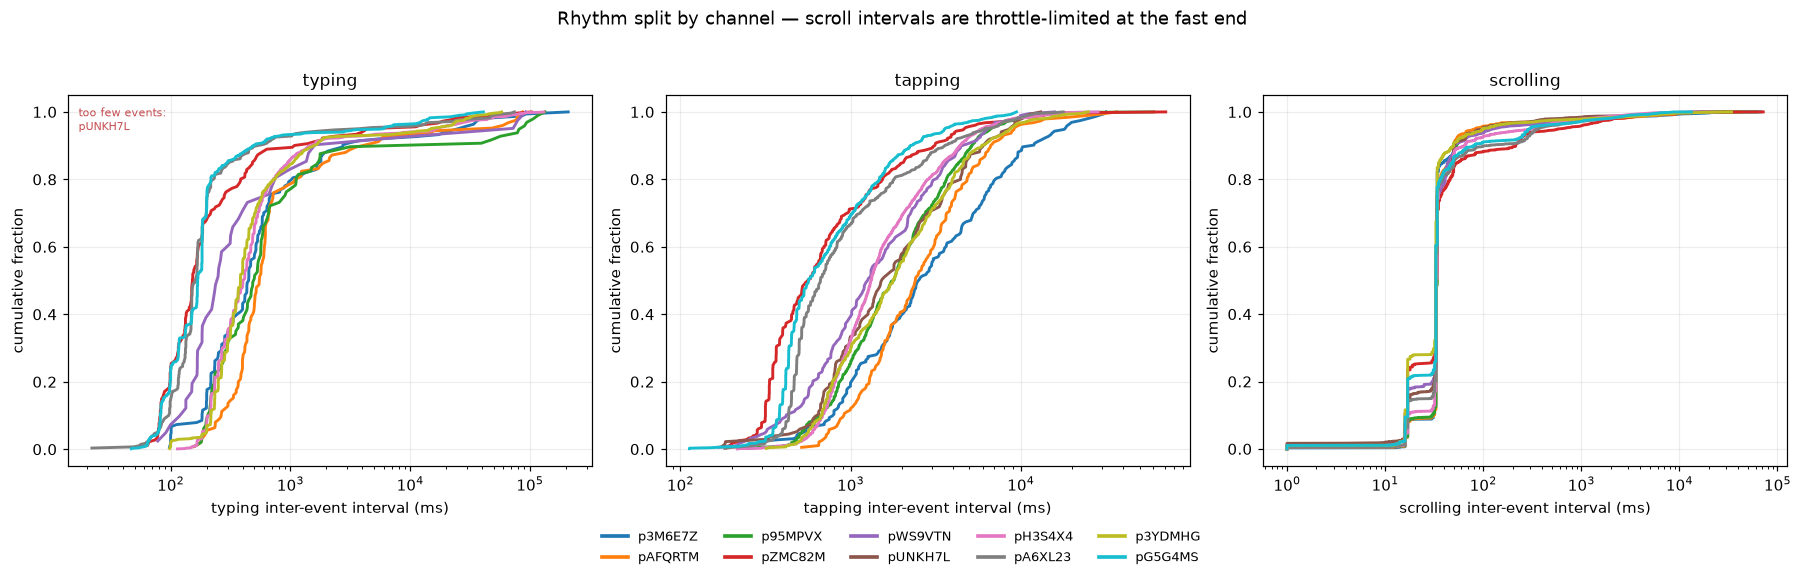

In [19]:
def plot_modality_panels(raw_df):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5))
    panels = [('typing', [KEY_DOWN]), ('tapping', [TAP_DOWN]), ('scrolling', SCROLL_KINDS)]
    for ax, (name, kinds) in zip(axes, panels):
        absent = []
        for p in PARTICIPANTS:
            vals = []
            for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
                v = intervals_for(raw_df.loc[raw_df['sessionId'] == sid], kinds)
                vals.append(v[np.isfinite(v) & (v > 0)])
            v = np.concatenate(vals) if vals else np.array([])
            if len(v) < 25:
                absent.append(p); continue
            v = np.sort(v)
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
        ax.set_xscale('log'); ax.set_xlabel(f"{name} inter-event interval (ms)")
        ax.set_ylabel("cumulative fraction"); ax.set_title(name)
        if absent:
            ax.text(0.02, 0.97, "too few events:\n" + ", ".join(absent), transform=ax.transAxes,
                    va='top', fontsize=7.5, color='#c44e52')
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False, fontsize=8.5)
    fig.suptitle("Rhythm split by channel — scroll intervals are throttle-limited at the fast end",
                 y=1.02)
    plt.tight_layout(rect=[0, 0.07, 1, 1]); plt.show(); plt.close(fig)


plot_modality_panels(raw)

## 15. Availability — who can be measured on what

Every plot above quietly drops participants who produced too few events. This section makes
that explicit, because a rhythm feature that cannot be computed for someone is a gap in a
model, not a neutral absence — and the gaps are not random.

             sessions  typing (keydown)  tapping (touchstart)  scrolling
participant                                                             
p3M6E7Z             1               165                   194       4080
pAFQRTM             1               126                   191       3345
p95MPVX             3               100                   600      10267
pZMC82M             1               182                   282       1973
pWS9VTN             1                42                   189       2817
pUNKH7L             1                19                   136       2554
pH3S4X4             8               930                  1486      26401
pA6XL23             2               283                   407       3524
p3YDMHG             4               513                   459       8369
pG5G4MS             6               691                   729       6274


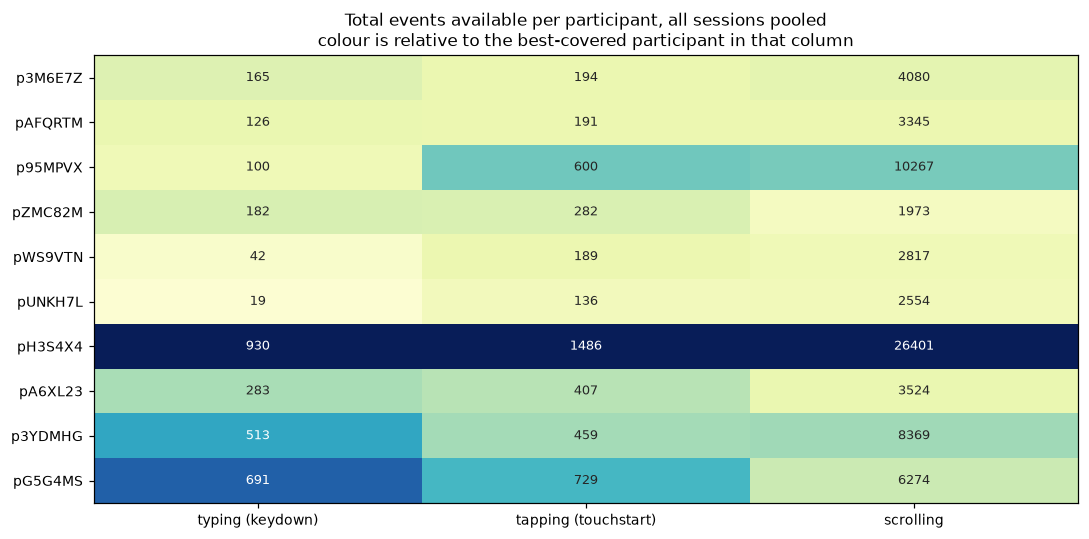


Typing-thin participants (< 150 keystrokes total): pAFQRTM, p95MPVX, pWS9VTN, pUNKH7L
Any typing-rhythm feature is fragile for these people.


In [20]:
avail_rows = []
for p in PARTICIPANTS:
    rec = {'participant': p,
           'sessions': int((session_index['participantId'] == p).sum())}
    for name, kinds in [('typing (keydown)', [KEY_DOWN]), ('tapping (touchstart)', [TAP_DOWN]),
                        ('scrolling', SCROLL_KINDS)]:
        n = 0
        for sid in session_index.loc[session_index['participantId'] == p, 'sessionId']:
            n += len(ev_times(raw.loc[raw['sessionId'] == sid], kinds))
        rec[name] = n
    avail_rows.append(rec)
avail = pd.DataFrame(avail_rows).set_index('participant')
print(avail.to_string())


def plot_availability(avail):
    fig, ax = plt.subplots(figsize=(10, 5))
    cols = [c for c in avail.columns if c != 'sessions']
    data = avail[cols].to_numpy(float)
    norm = data / np.maximum(data.max(axis=0), 1)
    im = ax.imshow(norm, cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, fontsize=9)
    ax.set_yticks(range(len(avail))); ax.set_yticklabels(avail.index, fontsize=9)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = int(data[i, j])
            ax.text(j, i, f"{v}", ha='center', va='center', fontsize=8.5,
                    color='white' if norm[i, j] > 0.55 else '0.15')
    ax.set_title("Total events available per participant, all sessions pooled\n"
                 "colour is relative to the best-covered participant in that column")
    ax.grid(False)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_availability(avail)
_thin = avail.loc[avail['typing (keydown)'] < 150]
if len(_thin):
    print(f"\nTyping-thin participants (< 150 keystrokes total): {', '.join(_thin.index)}")
    print("Any typing-rhythm feature is fragile for these people.")

## 16. Data-quality notes and rejected derivations

Kept here with reasons preserved, so nobody re-derives them expecting them to work.

- **Inter-scroll-event interval is not a rhythm measurement.** Scroll events fire on a browser
  throttle around 30 ms, so the gap between consecutive scroll events measures the throttle.
  Use burst structure (Section 7) instead.
- **`typing_dwell_ms` is close to a platform constant on mobile.** No key travel on a
  touchscreen; `keyup` follows `keydown` at browser dispatch speed (Section 12).
- **`touchmove` is coalesced by the browser**, so counts of move events per gesture are
  undersampled, and the undersampling is participant-correlated — slower gestures get more
  samples. Any "moves per tap" feature inherits that bias.
- **Rate features need the affordance mask; interval features do not** (Section 4). A rate has
  time in its denominator and returns a real-looking zero where the modality was never
  possible; an interval only exists where two events actually happened.
- **The 7.5 s operational window is too short for stable rate percentiles.** Section 9 uses
  20 s windows for readability. Anything computed at 7.5 s will be noisier than these plots
  suggest.
- **Session count is very uneven** (1 to 6 per participant). Pooled per-participant curves are
  dominated by whoever has the most sessions.

## 17. Per-participant rhythm cards

In [21]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['median_session_min'] = (session_index.groupby('participantId')['duration_s']
                              .median().reindex(PARTICIPANTS) / 60).round(1)
_it = iv_summary.loc[iv_summary['interval'] == 'inter-tap'].set_index('participant')
card['inter_tap_p50_ms'] = _it['median'].reindex(PARTICIPANTS).round(0)
card['inter_tap_p90_ms'] = _it['p90'].reindex(PARTICIPANTS).round(0)
_pp = iv_summary.loc[iv_summary['interval'] == 'press-to-press (typing)'].set_index('participant')
card['press_to_press_p50_ms'] = _pp['median'].reindex(PARTICIPANTS).round(0)
card['idle_pct'] = silence.groupby('p')['idle_pct'].median().reindex(PARTICIPANTS)
card['longest_pause_s'] = silence.groupby('p')['longest_pause_s'].max().reindex(PARTICIPANTS)
card['pauses_per_min'] = silence.groupby('p')['pauses_per_min'].median().reindex(PARTICIPANTS)
_reg = reg.loc[reg['interval'] == 'inter-tap'].set_index('participant')
card['tap_CV2_local'] = _reg['CV2_local'].reindex(PARTICIPANTS).round(2)
card['entry_latency_p50_ms'] = lat_summary.set_index('participant')['median_ms'].reindex(PARTICIPANTS).round(0)
card['switches_per_min'] = switch_summary.set_index('participant')['switches_per_min'].reindex(PARTICIPANTS).round(1)
card['touch_hold_p50_ms'] = dur_summary.set_index('participant')['hold_median_ms'].reindex(PARTICIPANTS).round(0)

print("Blank cells mean the quantity could not be computed for that person.")
print("Participants are ordered slowest-first by median session duration.\n")
print(card.to_string())

Blank cells mean the quantity could not be computed for that person.
Participants are ordered slowest-first by median session duration.

         sessions  median_session_min  inter_tap_p50_ms  inter_tap_p90_ms  press_to_press_p50_ms  idle_pct  longest_pause_s  pauses_per_min  tap_CV2_local  entry_latency_p50_ms  switches_per_min  touch_hold_p50_ms
p3M6E7Z         1                15.9            2531.0           11617.0                  449.0     57.10             31.0            6.00           0.86                5081.0               5.6              109.0
pAFQRTM         1                11.7            2403.0            6664.0                  552.0     50.10             36.4            7.30           0.73                2933.0               8.2              121.0
p95MPVX         3                 8.3            1800.0            5166.0                  499.0     36.40             60.4            4.70           0.69                1114.0              11.5              117.0
pZMC82M

## 18. Open questions

- **Speed and regularity look like separate axes (Section 8), but with 1-6 sessions per person
  there is no way to tell whether either is stable.** The same check that matters everywhere in
  this project — does a person's own repeat sessions agree — has not been run on any rhythm
  feature here.
- **Task-entry latency is the most directly comparable measurement in the notebook** (26
  identical transitions per session, 520 across the cohort) and has not been examined for
  whether it varies by task *type* — orientation time for a typing task and a swipe task are
  probably different things.
- **Bimodal interval distributions (Section 13) are visible for some participants.** Whether
  those two modes correspond to something identifiable — automatic versus deliberate actions,
  or simply different task types — is untested.
- **Modality switching (Section 11) is confounded by task design.** The task sequence dictates
  which modalities are available when, so some of the measured switching is the protocol
  rather than the person. Conditioning on task type would separate them.
- **The practice effect (Section 9) is measured on task duration, not on low-level rhythm.**
  Whether keystroke and tap timing also speed up on the second pass, or whether only the
  decision-making does, is a different and more interesting question.
- **Every participant is on their own handset.** Nothing here distinguishes a person's rhythm
  from their device's event-dispatch behaviour, though rhythm is far less exposed to this than
  amplitude features are.